# FLIM Analysis of EGFP and Maroon: Isolated Protein and Transiently Expressed in U2OS

## Loading Necessary Script

In [246]:
import os
import sys
import io
import numpy as np
import scipy.optimize as optimize
import matplotlib.pyplot as plt

from matplotlib import rcParams
%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (16, 12)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16

import pq_decoding_functions as pq
import flim_fitting_functions as fit

## Fitting Simulated Data

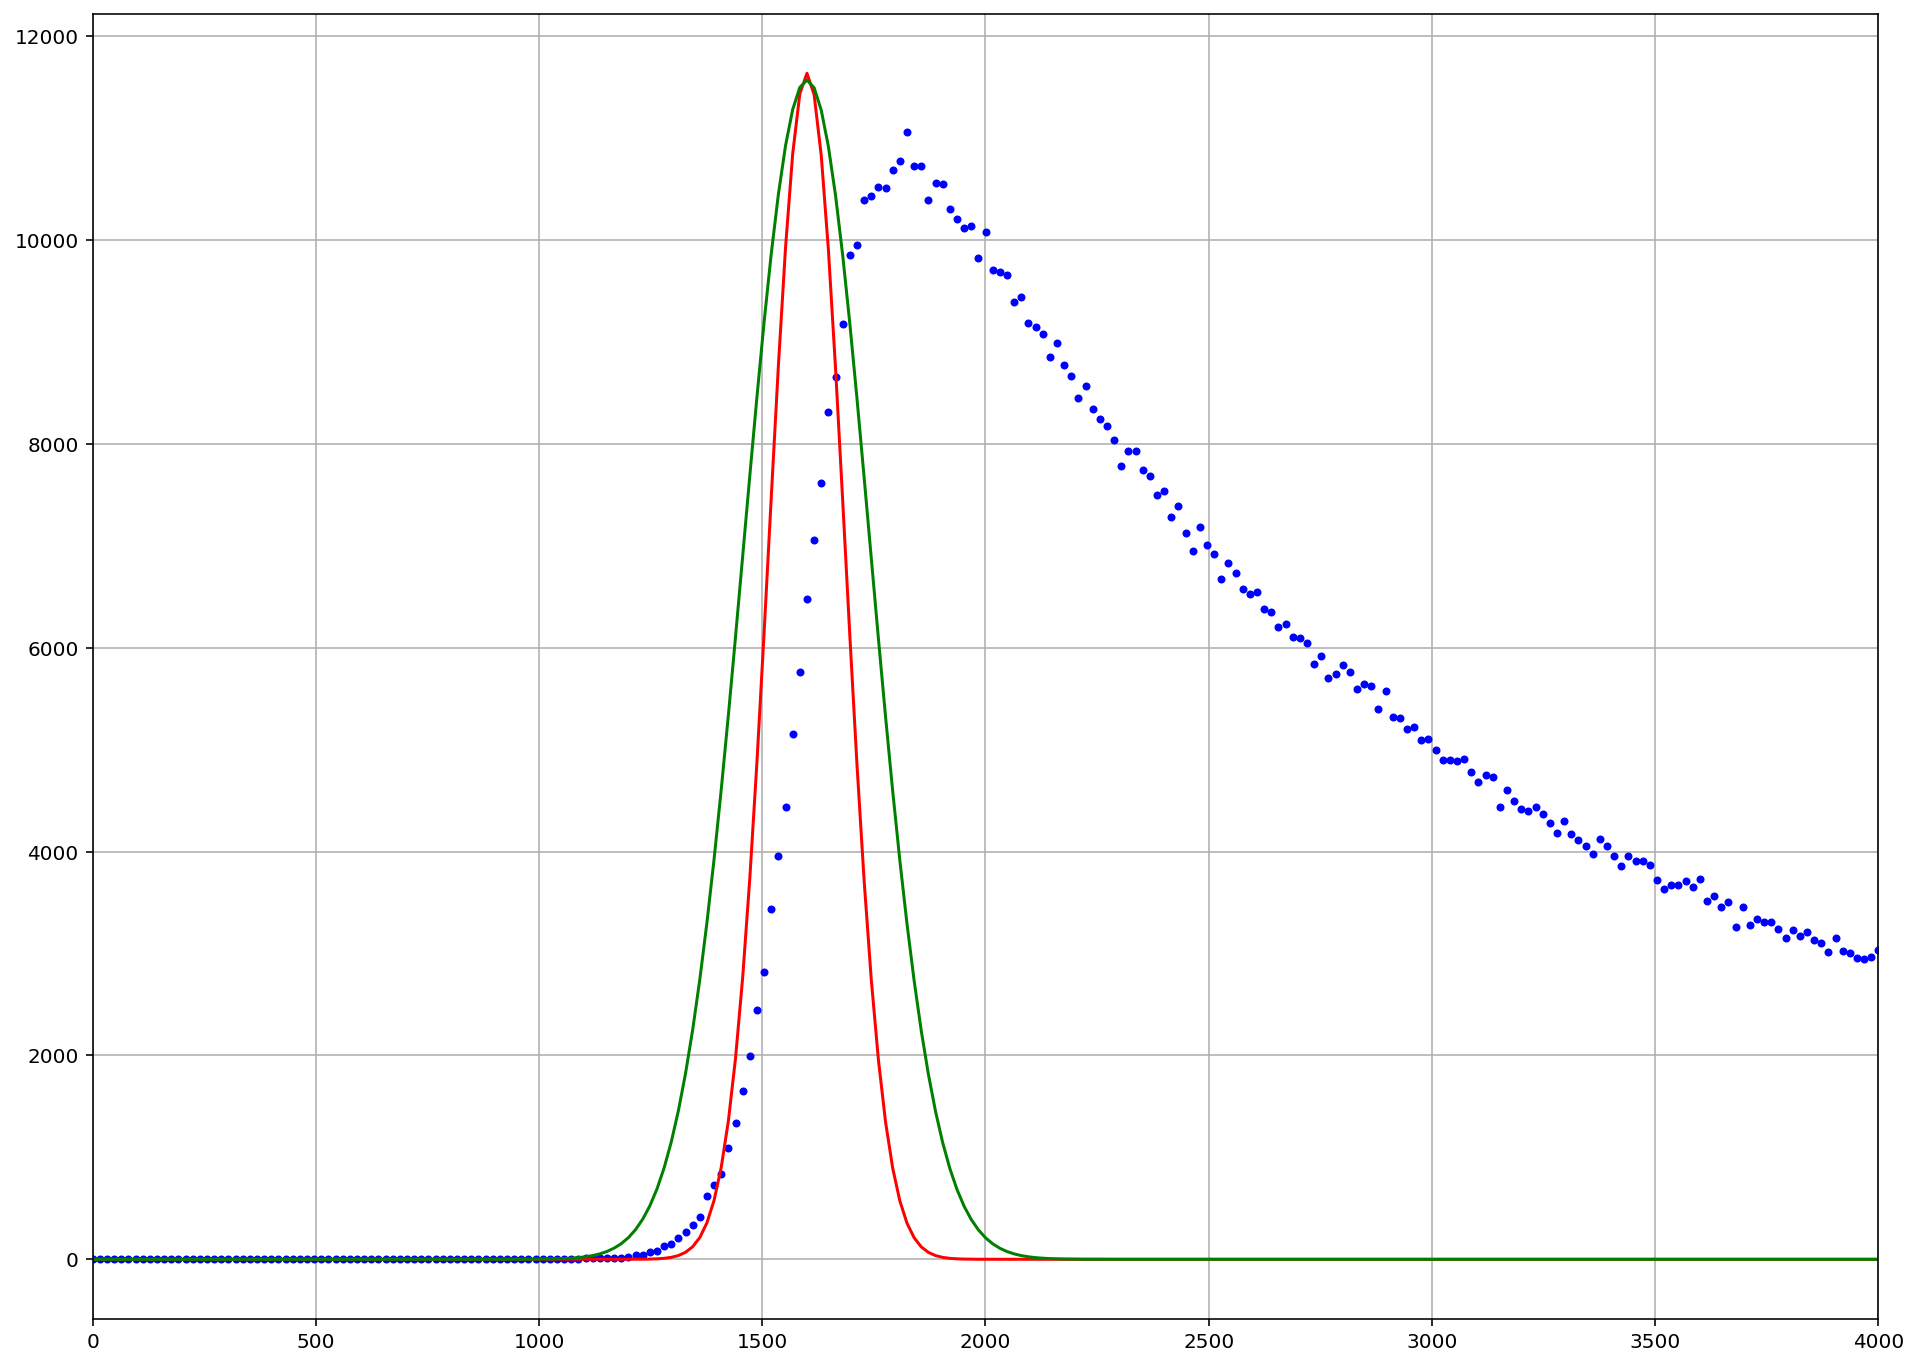

In [247]:
time_axis = pq.make_time_axis(
    global_resolution = 1/19450000,
    resolution = 1.6E-11,
)


def add_poisson_noise(data, offset):
    decay = np.random.poisson(data, len(data))
    decay += np.random.poisson(offset, len(decay))
    return(decay)

simulated = fit.convoluted_decay(
    t = time_axis,
    offset = 1,
    amp = 5000,
    tau = 3210,
    IRF_mu = 1600,
    IRF_sigma = 60
)

simulated += fit.convoluted_decay(
    t = time_axis,
    offset = 1,
    amp = 10000,
    tau = 1000,
    IRF_mu = 1600,
    IRF_sigma = 100
)

simulated = add_poisson_noise(simulated, offset = 1)

IRF_1 = fit.gauss_laser(time_axis, 1600, 60)
IRF_2 = fit.gauss_laser(time_axis, 1600, 100)

plt.plot(time_axis, simulated, 'b.')
plt.plot(time_axis, 1750000*IRF_1, 'r-')
plt.plot(time_axis, 2900000*IRF_2, 'g-')
plt.yscale('linear')
plt.xlim(0, 4000)
plt.grid()
#plt.savefig('../../../../../Desktop/SimDecay_IRF_mu_diff.png', dpi = 350)
plt.show()


Reduced Chi-Squared: 16.0558462934027


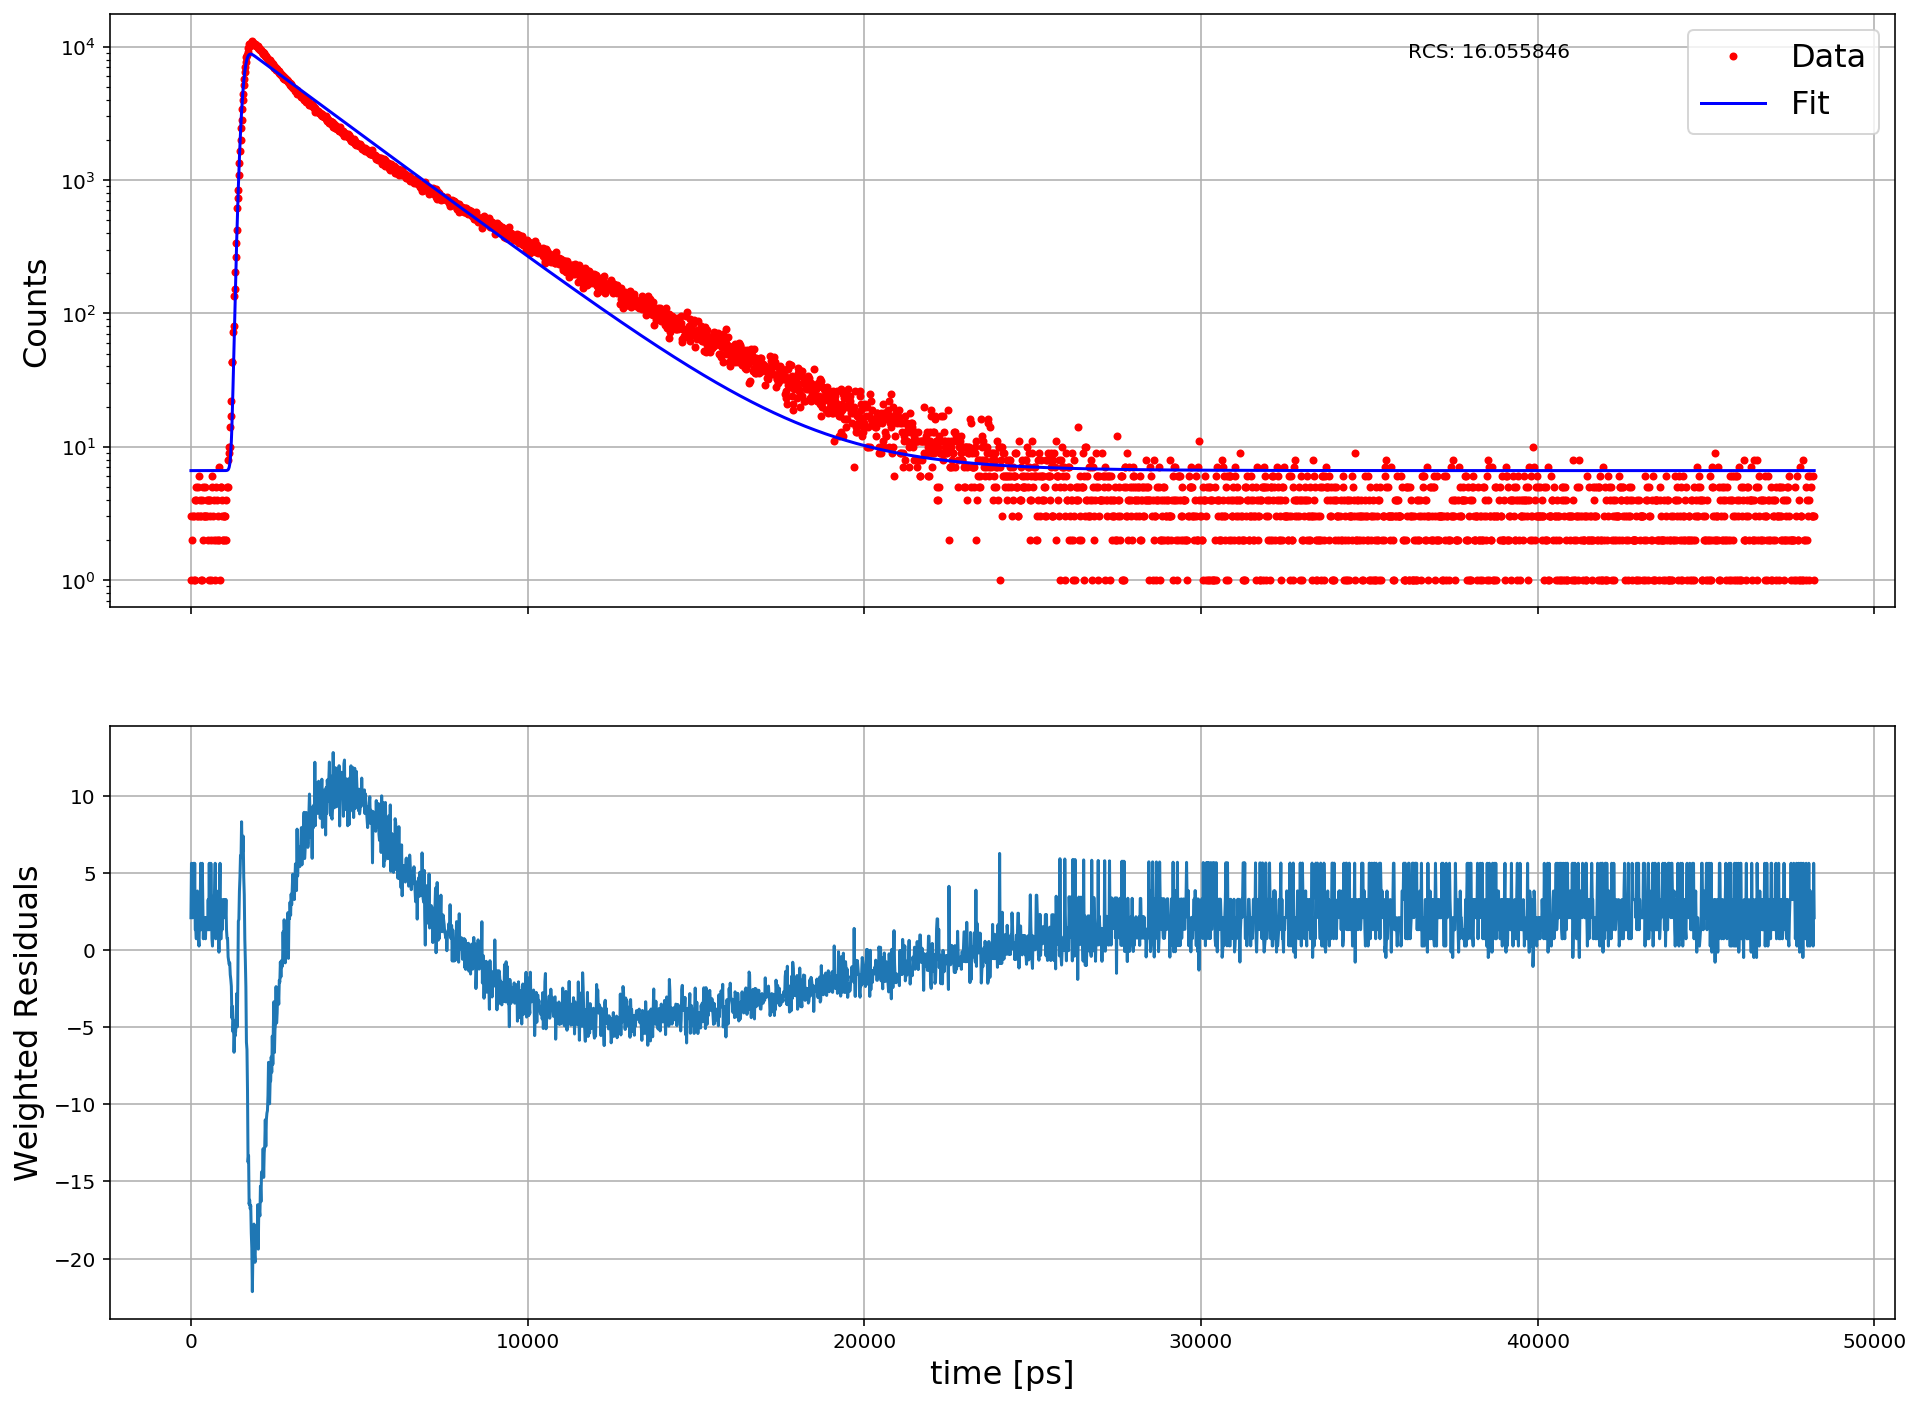

offset 		 6.617532568467726
amplitude 		 11116.728461744771
tau 		 2329.5218519169557
IRF_mu 		 1555.4818797358244
IRF_sigma 		 74.01427455087641


In [248]:
# Fitting simulated data
parameter_names, estimated_parameters, parameter_bounds = fit.make_start_parameters(
    offset = 2,
    amplitude = max(simulated),
   # Scatter_amplitude = 100,
    tau = 1000
)

simulated_fit = fit.fit_decay(
    simulated,
    time_axis,
    estimated_parameters,
    parameter_bounds,
    cutoff = 500,
    minimization_method = 'SLSQP'
)


fit.plot_fit(simulated, time_axis, simulated_fit, cutoff = 200, scale = 'log')

for i in range(0, len(parameter_names)):
    print(parameter_names[i], '\t\t', simulated_fit['x'][i])


## Coumarin 6, 500 Integrations (45 min @ ~ 10 kCPS)
### Transient Expression

In [254]:
#ptu_path = '../../../FLIM Data/20200318_Coumarin6_Long_Integration/200318_Coumarin_Long_Integration.sptw/200318_Coumarin6_LongIntegration_1/200318_Coumarin6_LongIntegration_1_1.ptu'
ptu_path = '../../../FLIM Data/Praktikum_Biochemie/raw_data/FP_EGFP_Maroon_200312.sptw/Kontrolle_Sulforhodamine101_10µM_1_1_1.ptu'
EGFP_cell_fa, EGFP_cell_ii, time_axis= pq.load_flim_data(
    path = ptu_path,
    channel = 1,
    spatialBinning = 4,
    temporalBinning = 2
)



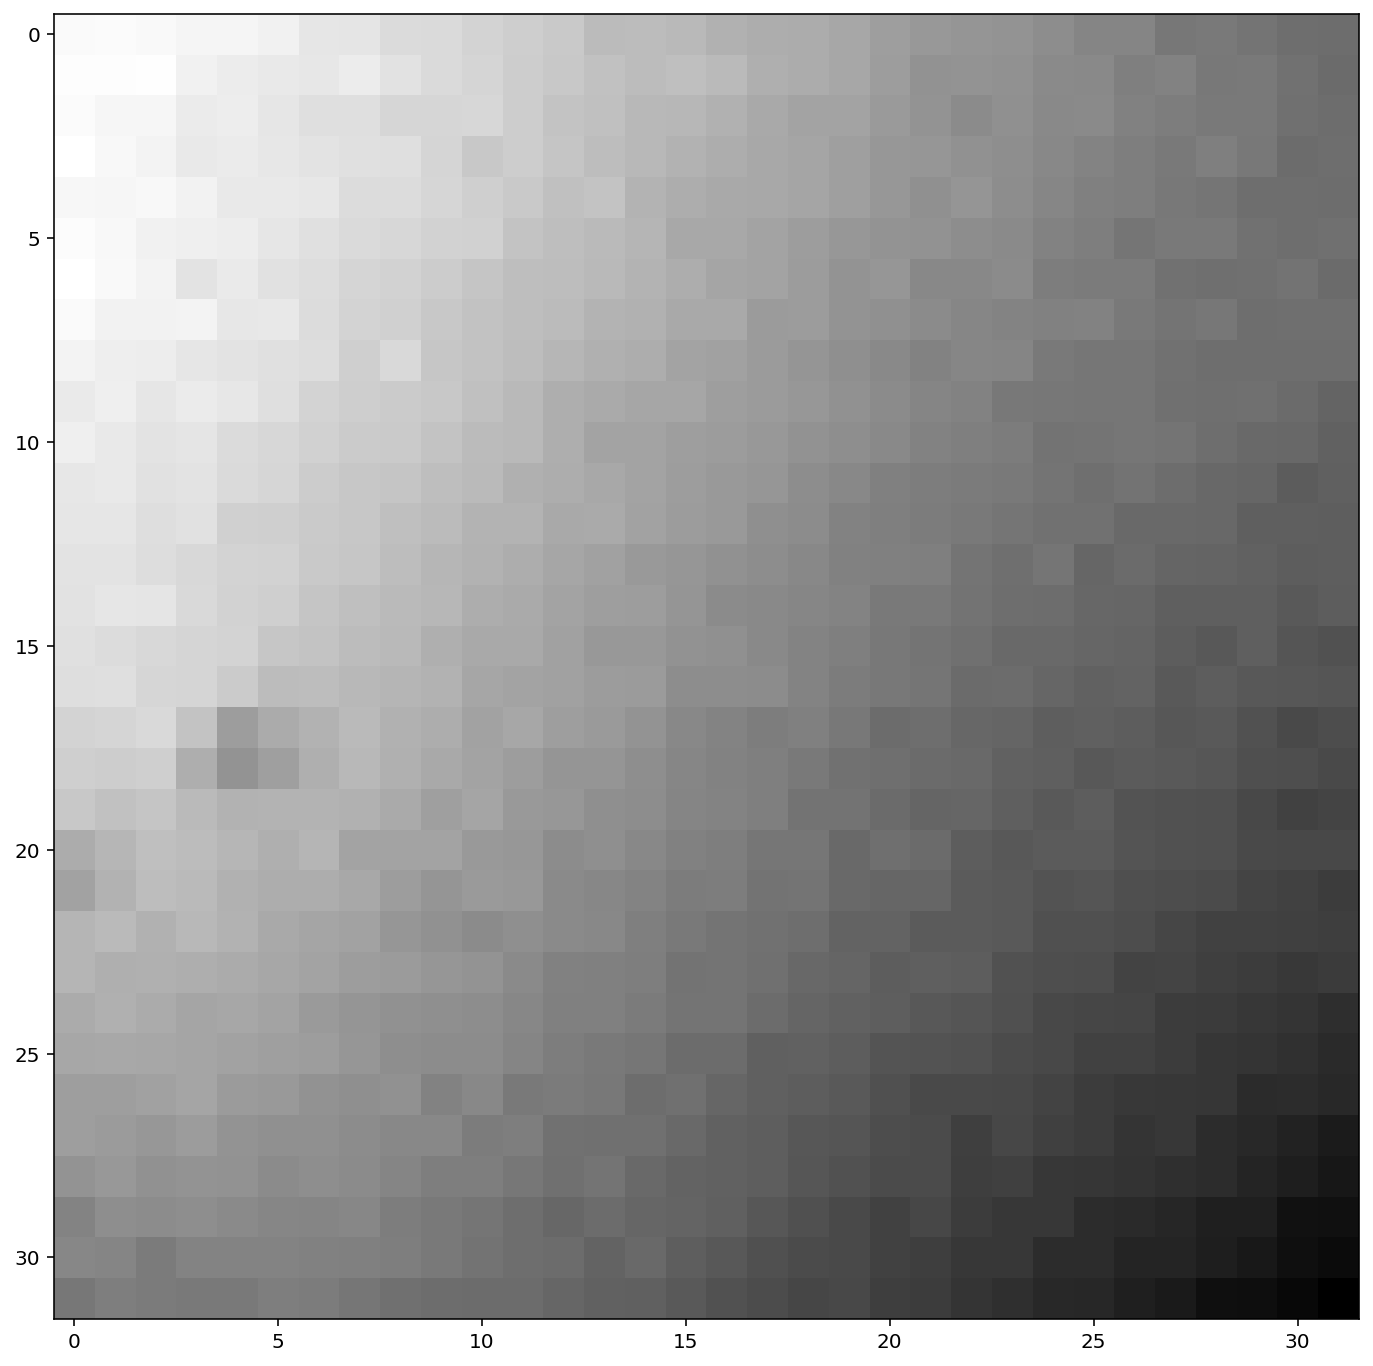

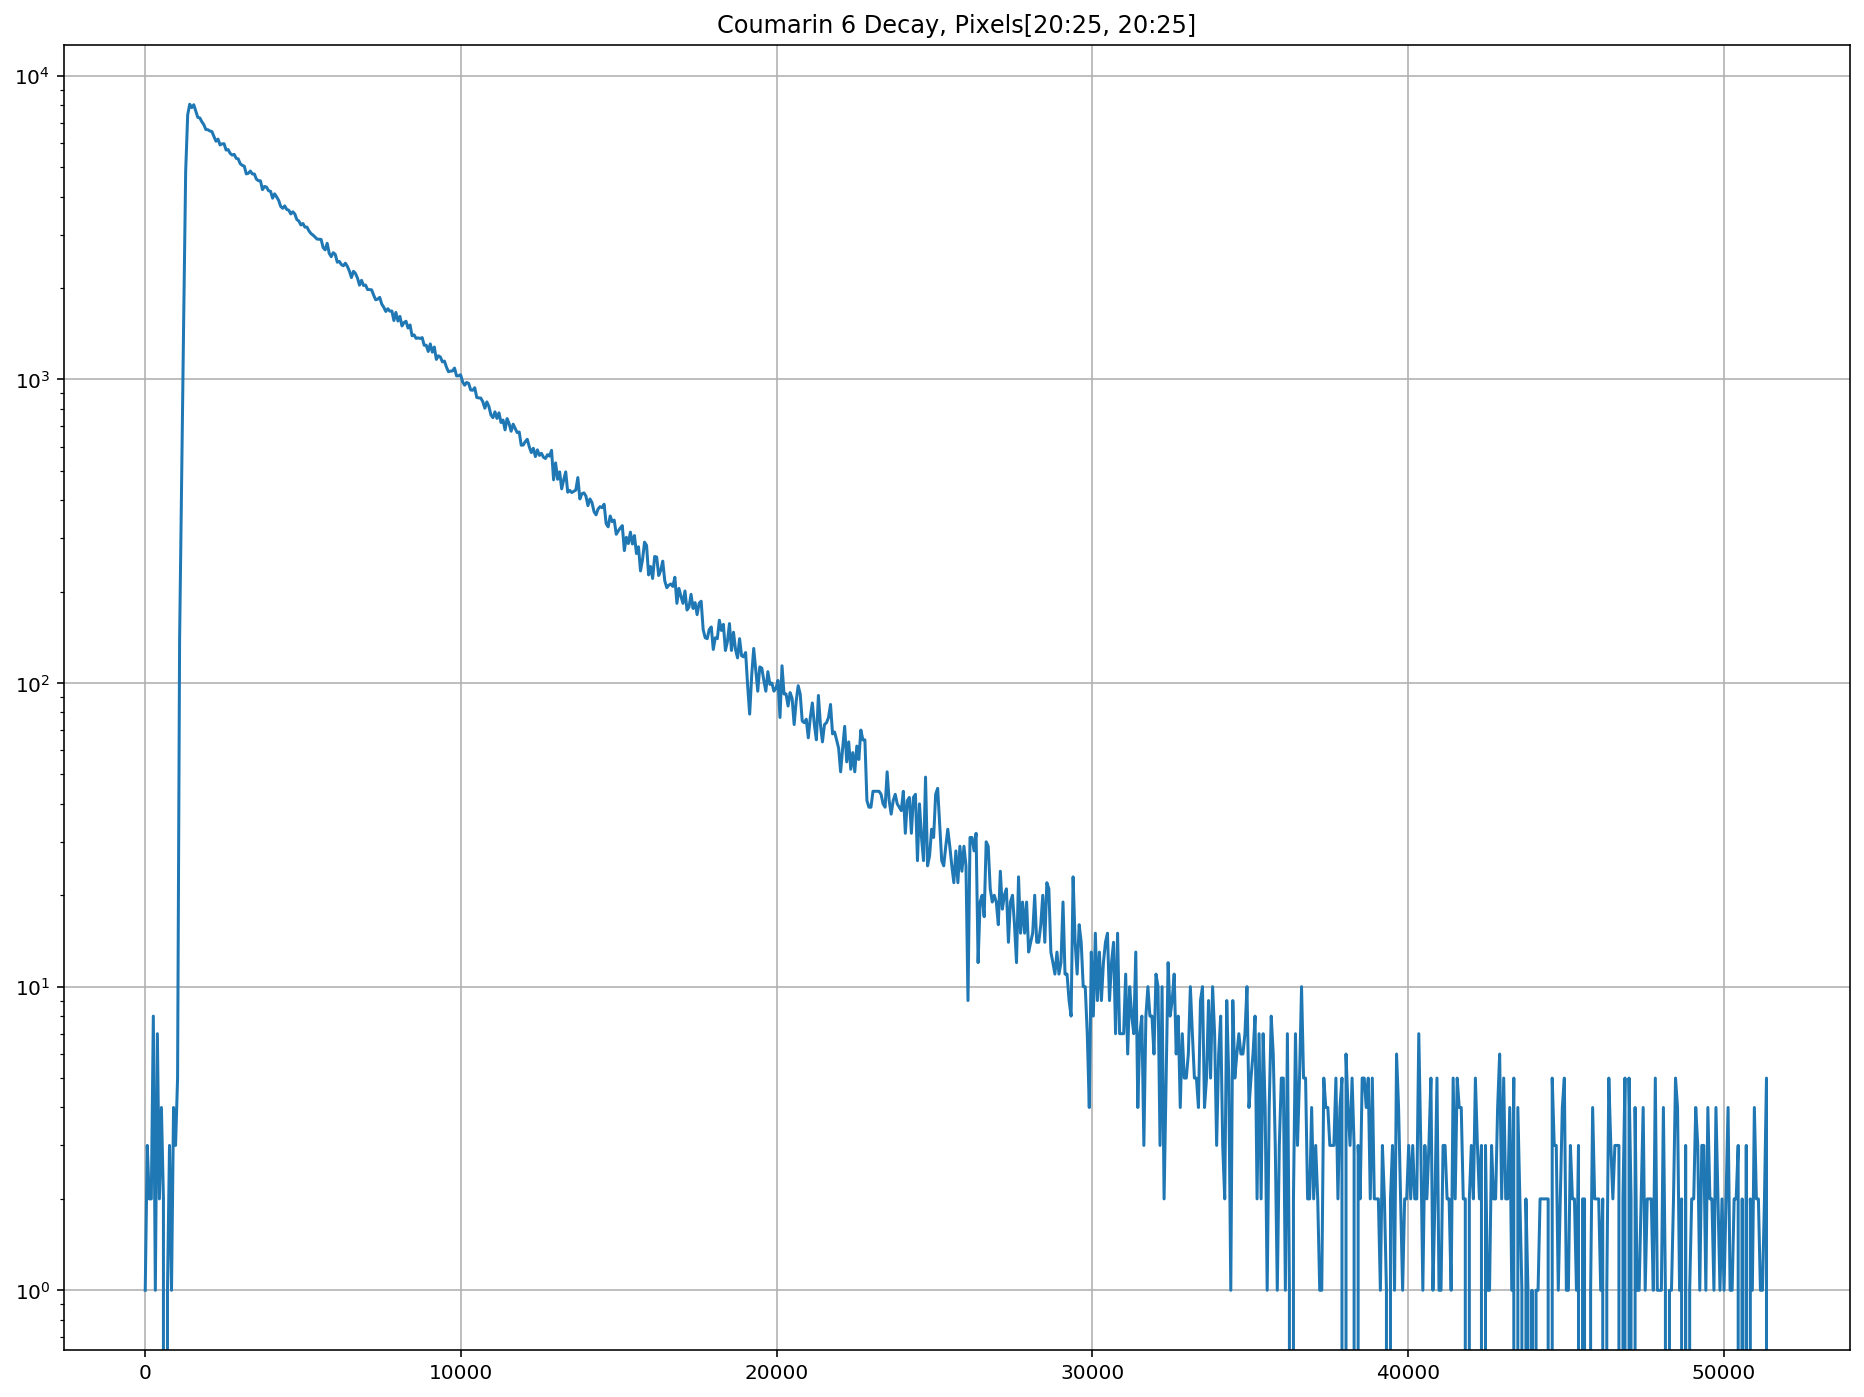

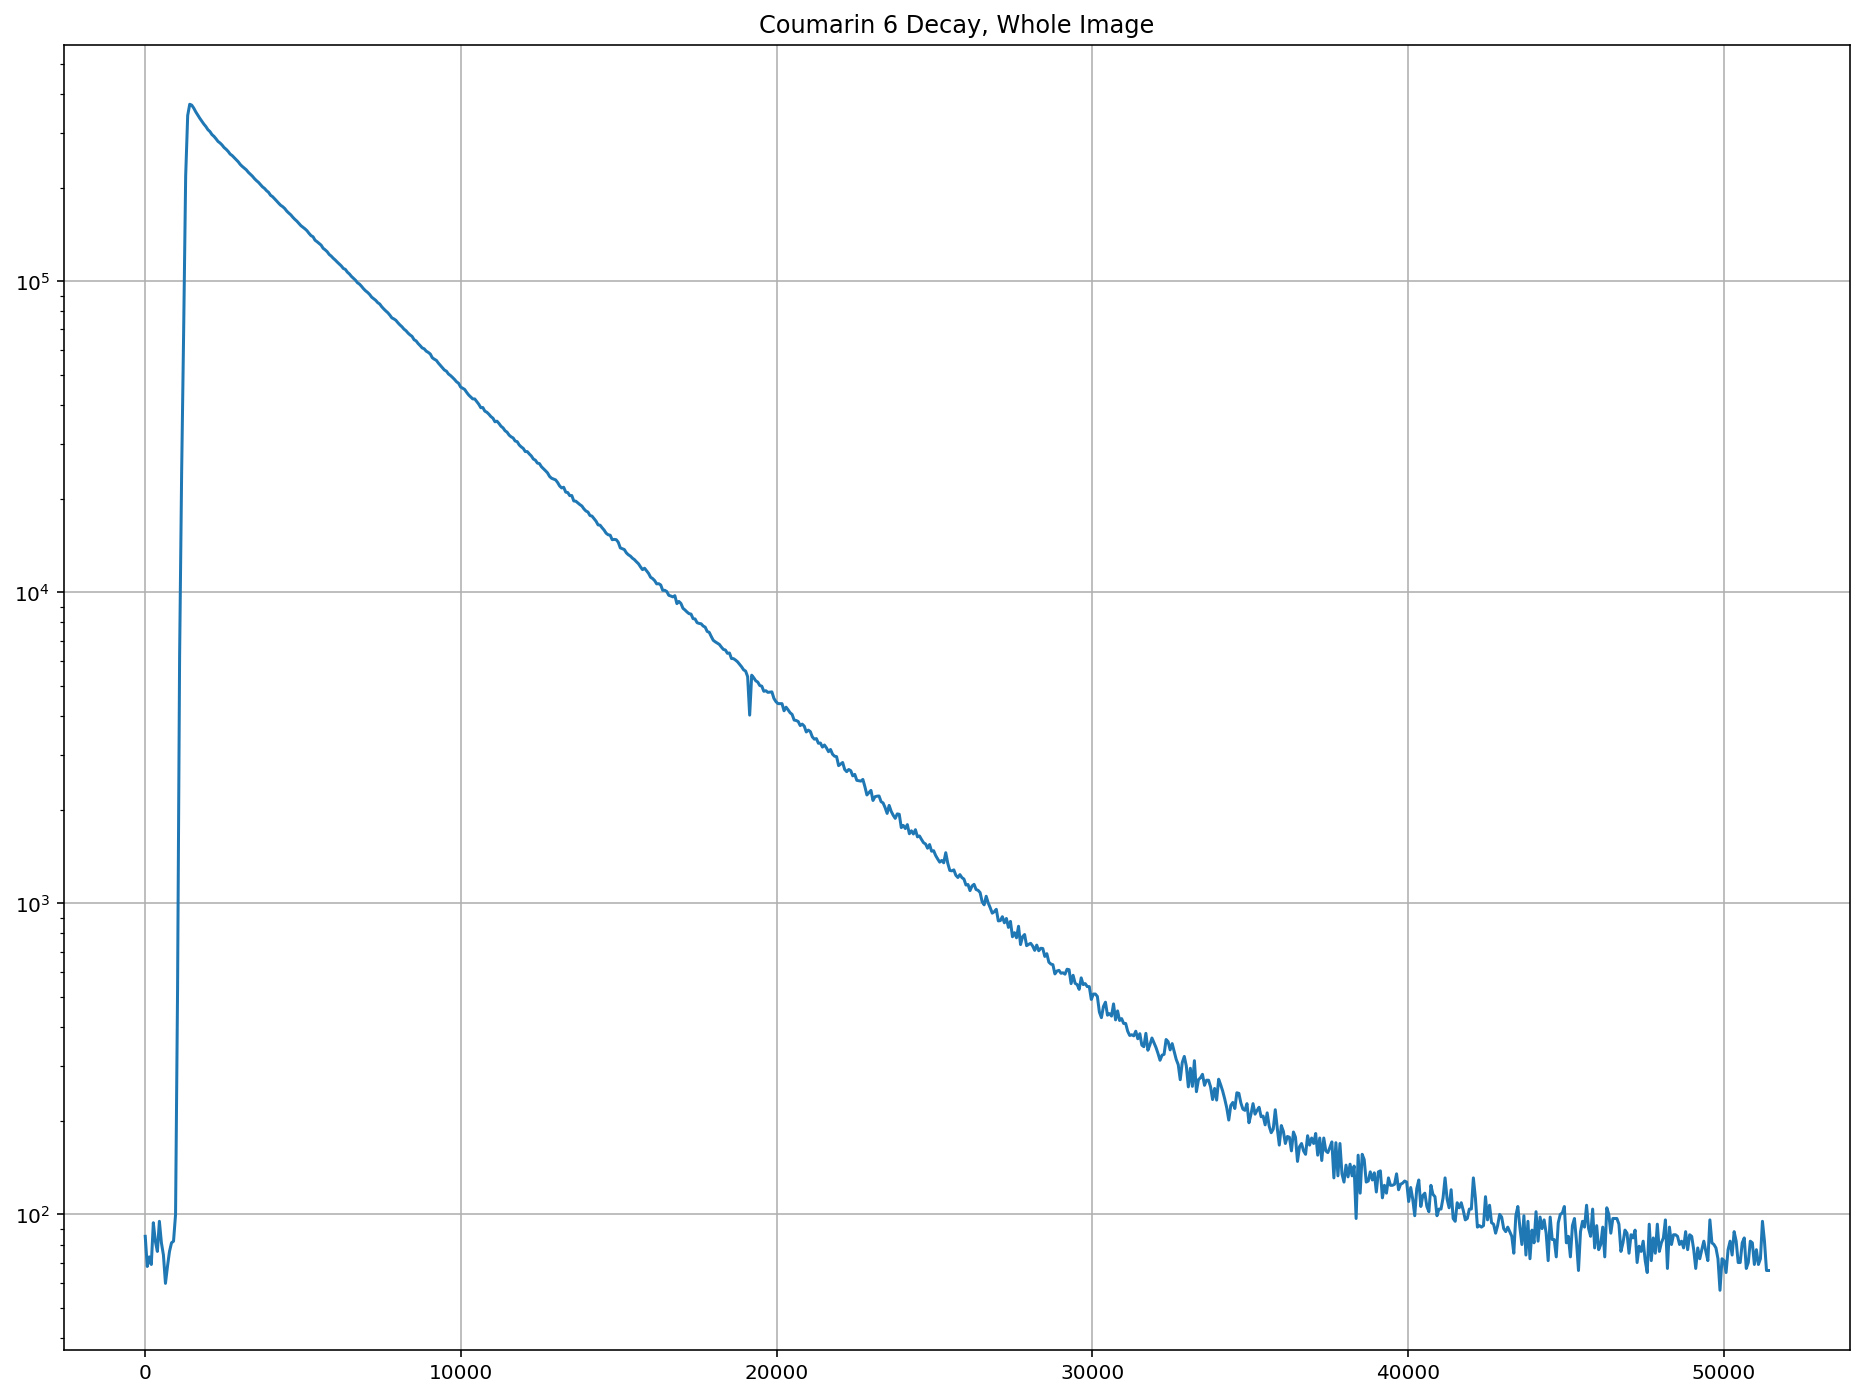

In [255]:
plt.imshow(EGFP_cell_ii, cmap = 'gray')
plt.show()

EGFP_decay_all = fit.sum_up_decay(EGFP_cell_fa)
EGFP_decay = fit.sum_up_decay(EGFP_cell_fa[20:25, 20:25, :])

plt.plot(time_axis, EGFP_decay)
plt.yscale('log')
plt.grid()
plt.title('Coumarin 6 Decay, Pixels[20:25, 20:25]')
plt.show()

plt.plot(time_axis, EGFP_decay_all)
plt.grid()
plt.yscale('log')
plt.title('Coumarin 6 Decay, Whole Image')
plt.show()

### Fitting Decay from Whole Image

In [256]:
# Fitting Decay of Whole Image

parameter_names, estimated_parameters, parameter_bounds = fit.make_start_parameters(
    offset = 2,
    amplitude = max(EGFP_decay_all),
    #Scatter_amplitude = 0,
    tau = 2000
    #IRF_sigma = 25
)

EGFP_fit = fit.fit_decay(
    EGFP_decay_all,
    time_axis,
    estimated_parameters,
    parameter_bounds,
    cutoff = 500,
    minimization_method = 'SLSQP'
)

fit.plot_fit(EGFP_decay_all, time_axis, EGFP_fit, cutoff = 2900, scale = 'log')

for i in range(0, len(parameter_names)):
    print(parameter_names[i], '\t\t', EGFP_fit['x'][i])

ValueError: 'a' cannot be empty

### Fitting Selected Pixels[20:25, 20:25]

In [259]:
parameter_names, estimated_parameters, parameter_bounds = fit.make_start_parameters(
    offset = 2,
    amplitude = max(EGFP_decay),
    #Scatter_amplitude = 0,
    tau = 2500
    #IRF_sigma = 25
)

EGFP_fit = fit.fit_decay(
    EGFP_decay,
    time_axis,
    estimated_parameters,
    parameter_bounds,
    cutoff = 10,
    minimization_method = 'SLSQP'
)


Reduced Chi-Squared: 2.7211006453563438


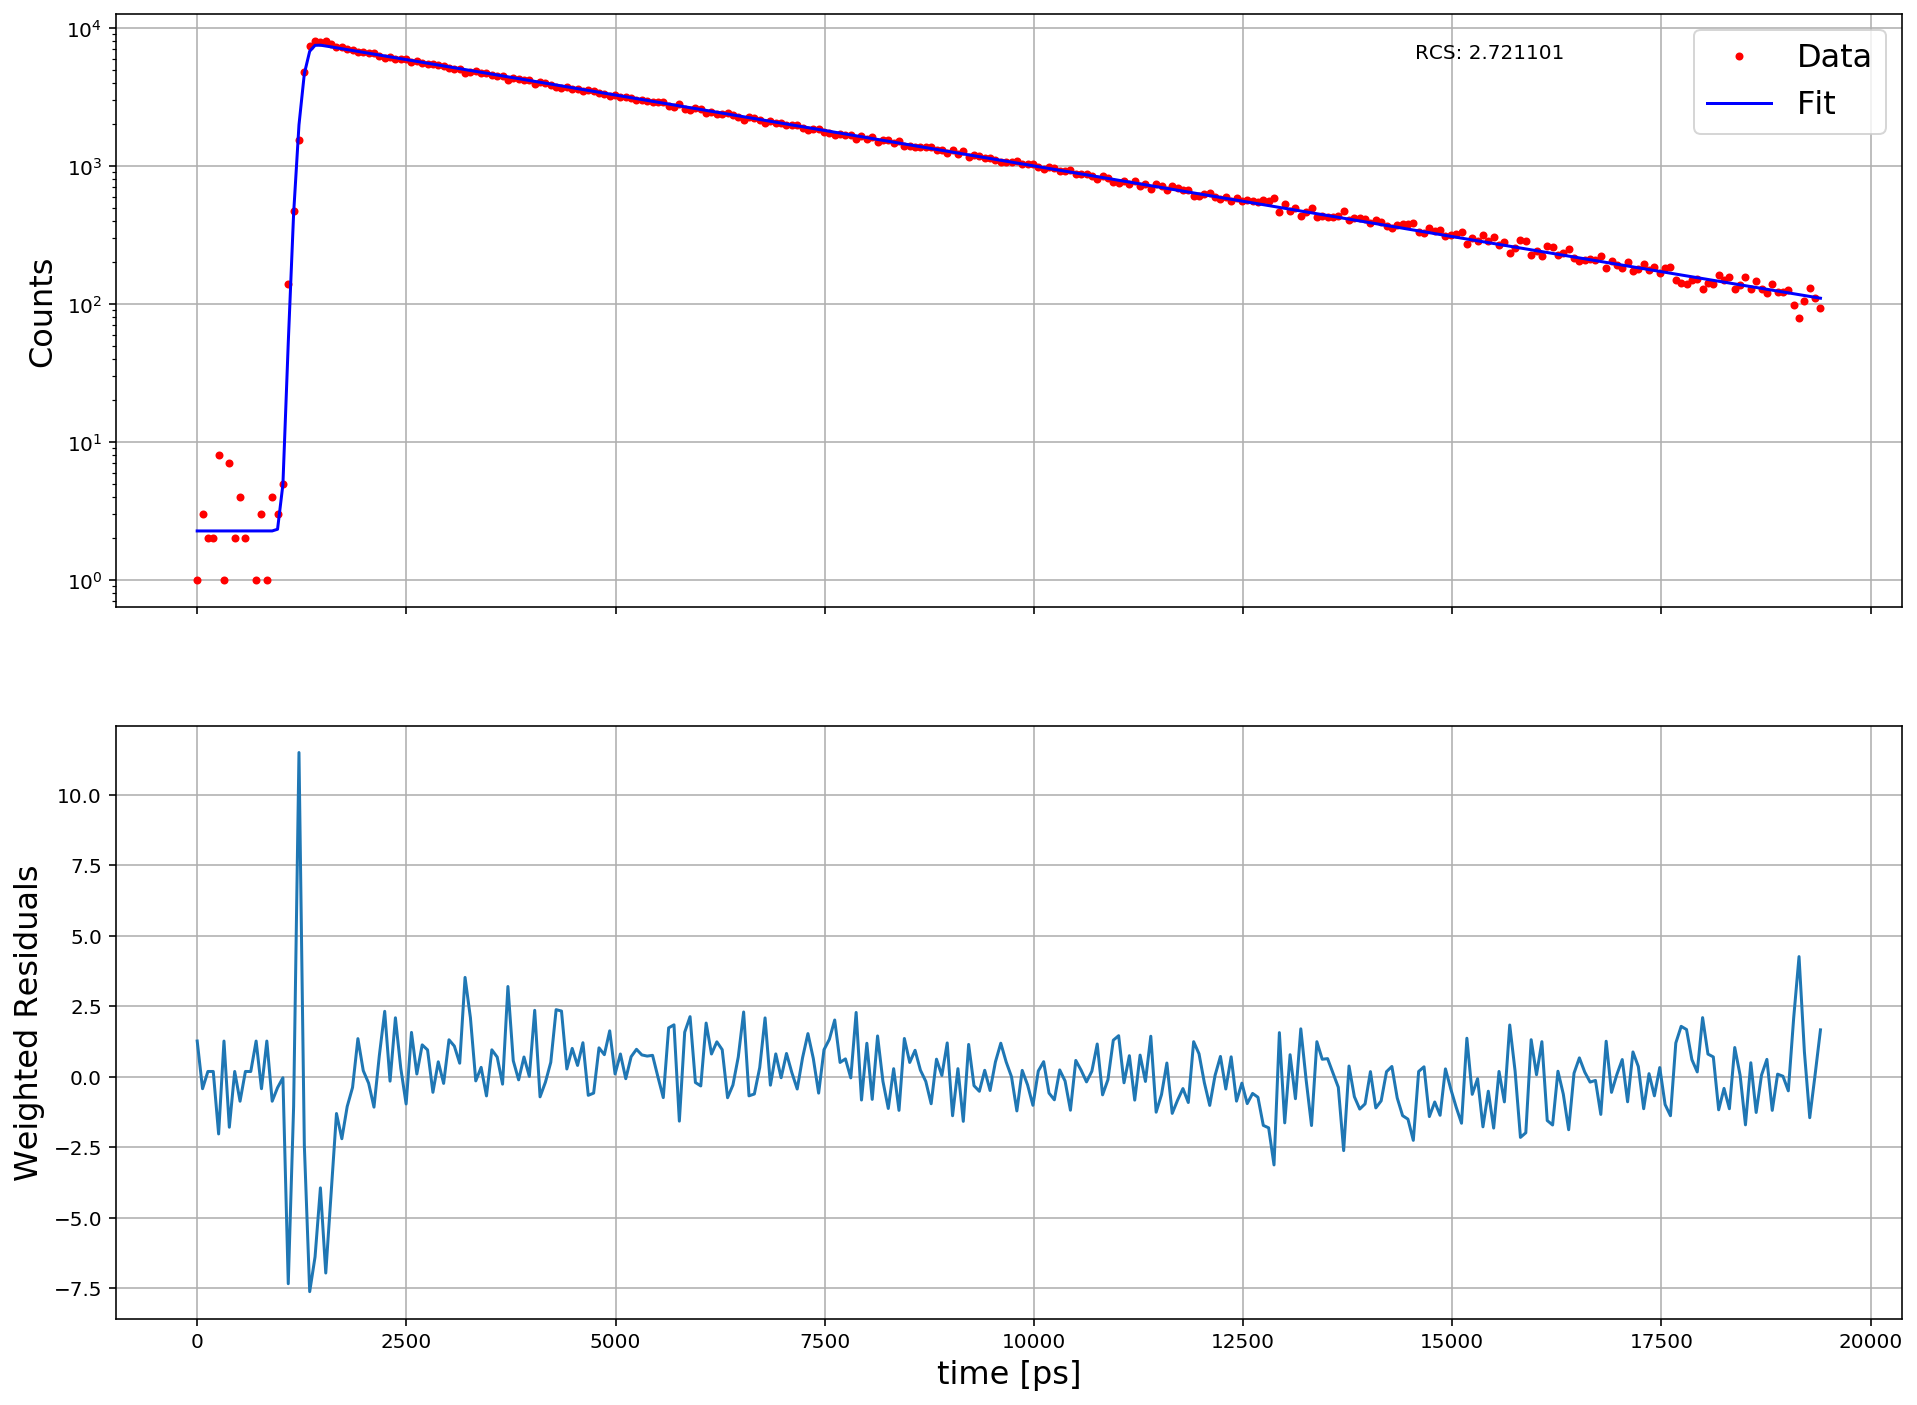

offset 		 2.2676270360194413
amplitude 		 35483.20408348968
tau 		 4224.405369132564
IRF_mu 		 1294.8224590735088
IRF_sigma 		 51.199682341521964


In [260]:
fit.plot_fit(EGFP_decay, time_axis, EGFP_fit, cutoff = 500, scale = 'log')

for i in range(0, len(parameter_names)):
    print(parameter_names[i], '\t\t', EGFP_fit['x'][i])

In [261]:
# Pixel-wise fitting

flim_image = np.zeros((EGFP_cell_fa.shape[0], EGFP_cell_fa.shape[1], EGFP_fit['x'].shape[0]))

for x in range(EGFP_cell_fa.shape[0]):
    for y in range(EGFP_cell_fa.shape[1]):
        estimated_parameters = EGFP_fit['x']
        if(np.sum(EGFP_cell_fa[x, y, :]) > 300):
            EGFP_fit = fit.fit_decay(
                EGFP_cell_fa[x, y, :],
                time_axis,
                estimated_parameters,
                parameter_bounds,
                cutoff = 750,
                minimization_method = 'SLSQP'
            )
            flim_image[x, y, :] = EGFP_fit['x']
    print('Proceeding to line', x)

/home/tom/Documents/PhD/Repositories/PhasorFLIM/notebooks/flim_fitting_functions.py:143: RuntimeWarning: invalid value encountered in true_divide
  data * np.log(data / fitted) - (data - fitted)


Proceeding to line 0


/home/tom/Documents/PhD/Repositories/PhasorFLIM/notebooks/flim_fitting_functions.py:143: RuntimeWarning: overflow encountered in true_divide
  data * np.log(data / fitted) - (data - fitted)


Proceeding to line 1
Proceeding to line 2
Proceeding to line 3
Proceeding to line 4
Proceeding to line 5
Proceeding to line 6
Proceeding to line 7
Proceeding to line 8
Proceeding to line 9
Proceeding to line 10
Proceeding to line 11
Proceeding to line 12
Proceeding to line 13
Proceeding to line 14
Proceeding to line 15
Proceeding to line 16
Proceeding to line 17
Proceeding to line 18
Proceeding to line 19
Proceeding to line 20
Proceeding to line 21
Proceeding to line 22
Proceeding to line 23
Proceeding to line 24
Proceeding to line 25
Proceeding to line 26
Proceeding to line 27
Proceeding to line 28
Proceeding to line 29
Proceeding to line 30
Proceeding to line 31


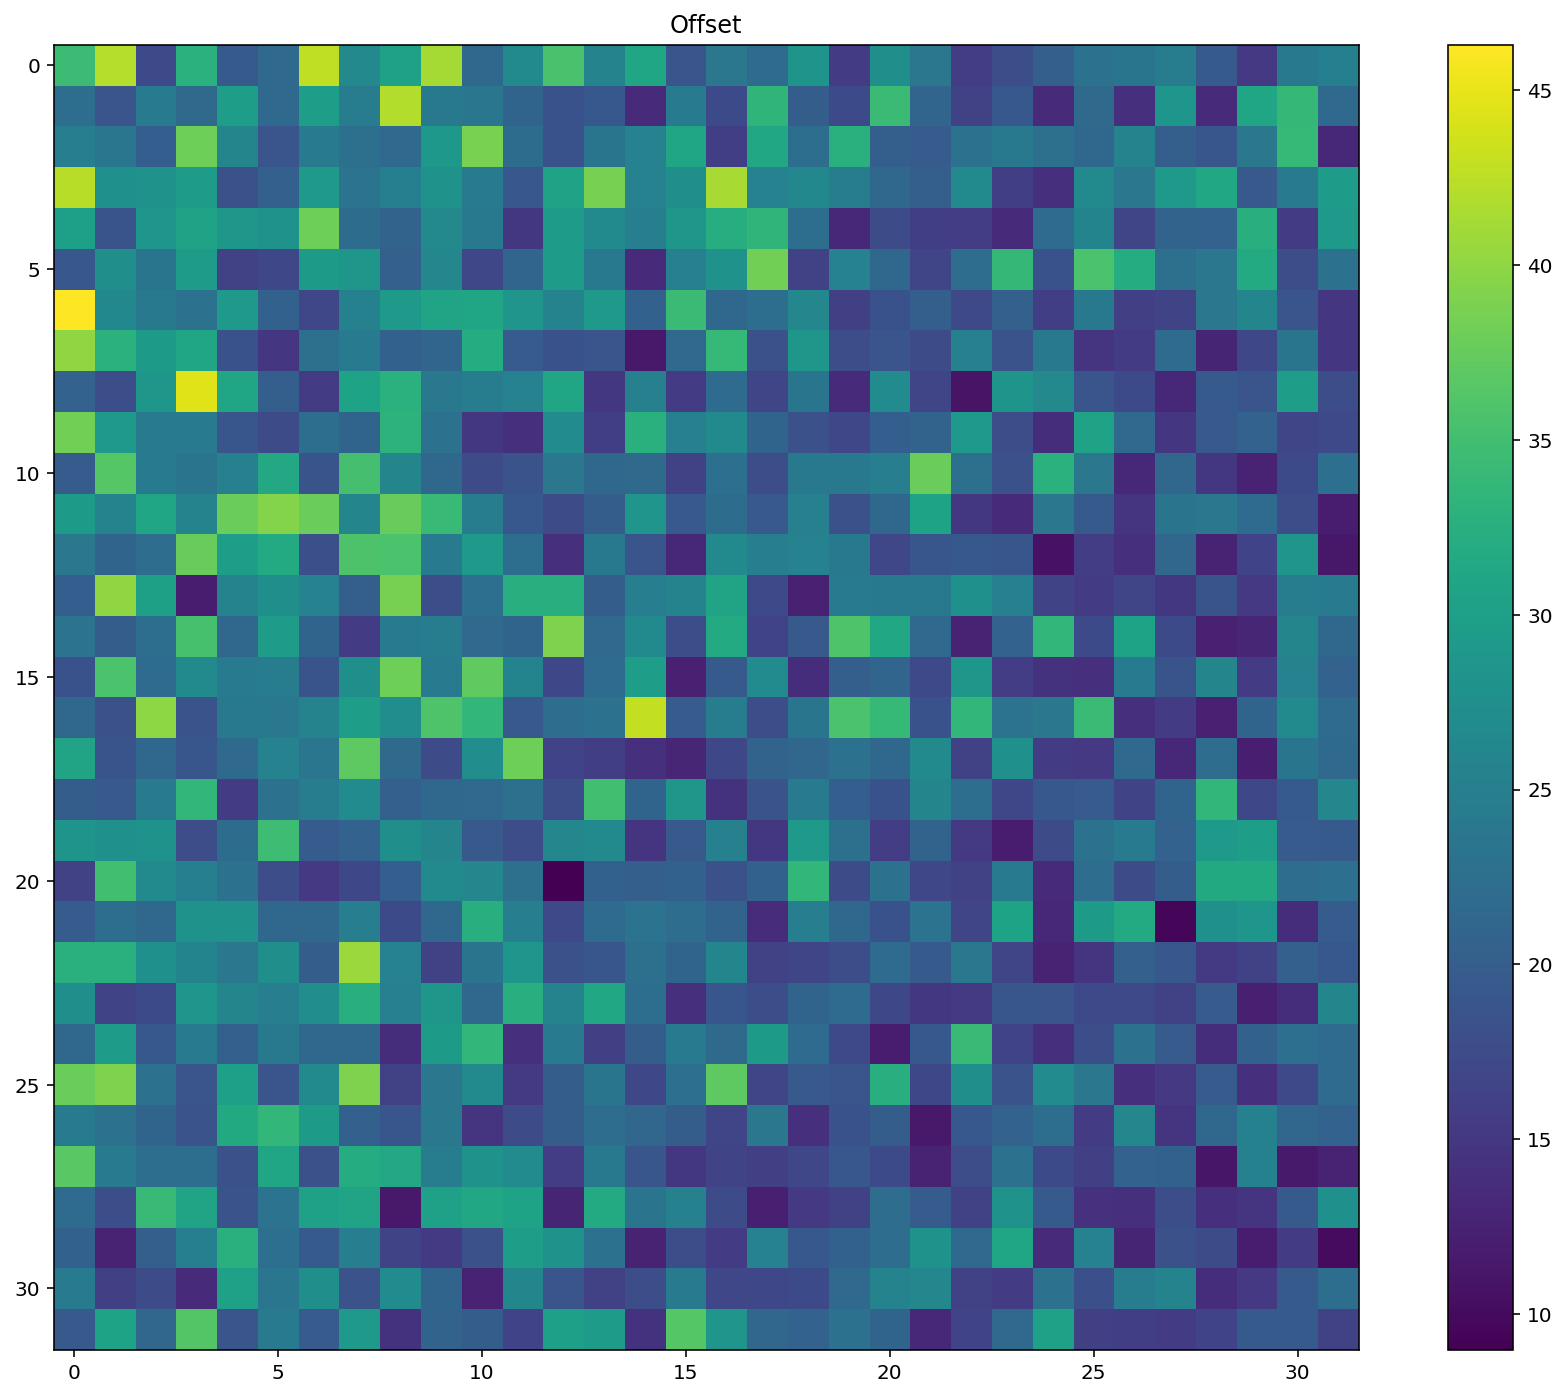

In [262]:
plt.imshow(flim_image[:, :, 0])
plt.title('Offset')
plt.colorbar()
plt.show()

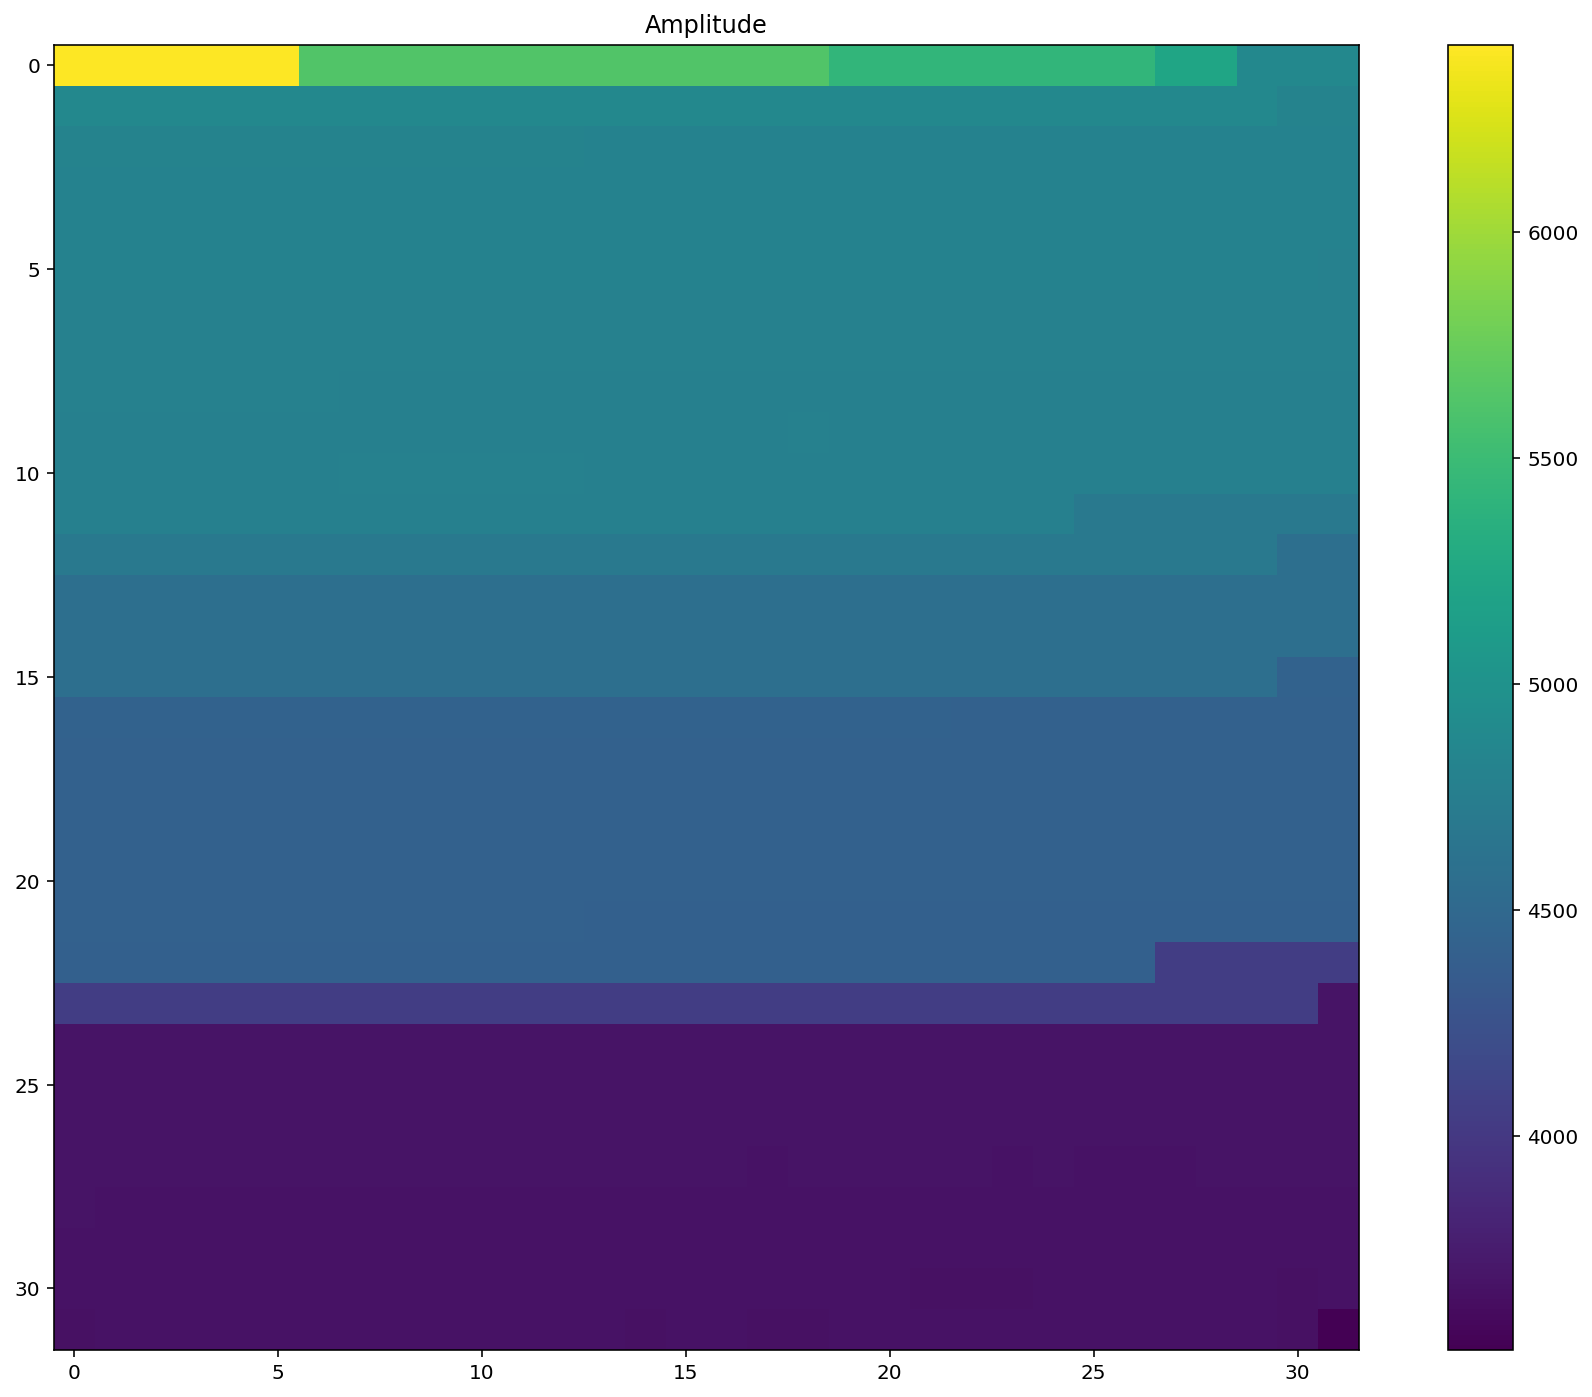

In [263]:
plt.imshow(flim_image[:, :, 1])
plt.title('Amplitude')
plt.colorbar()
plt.show()

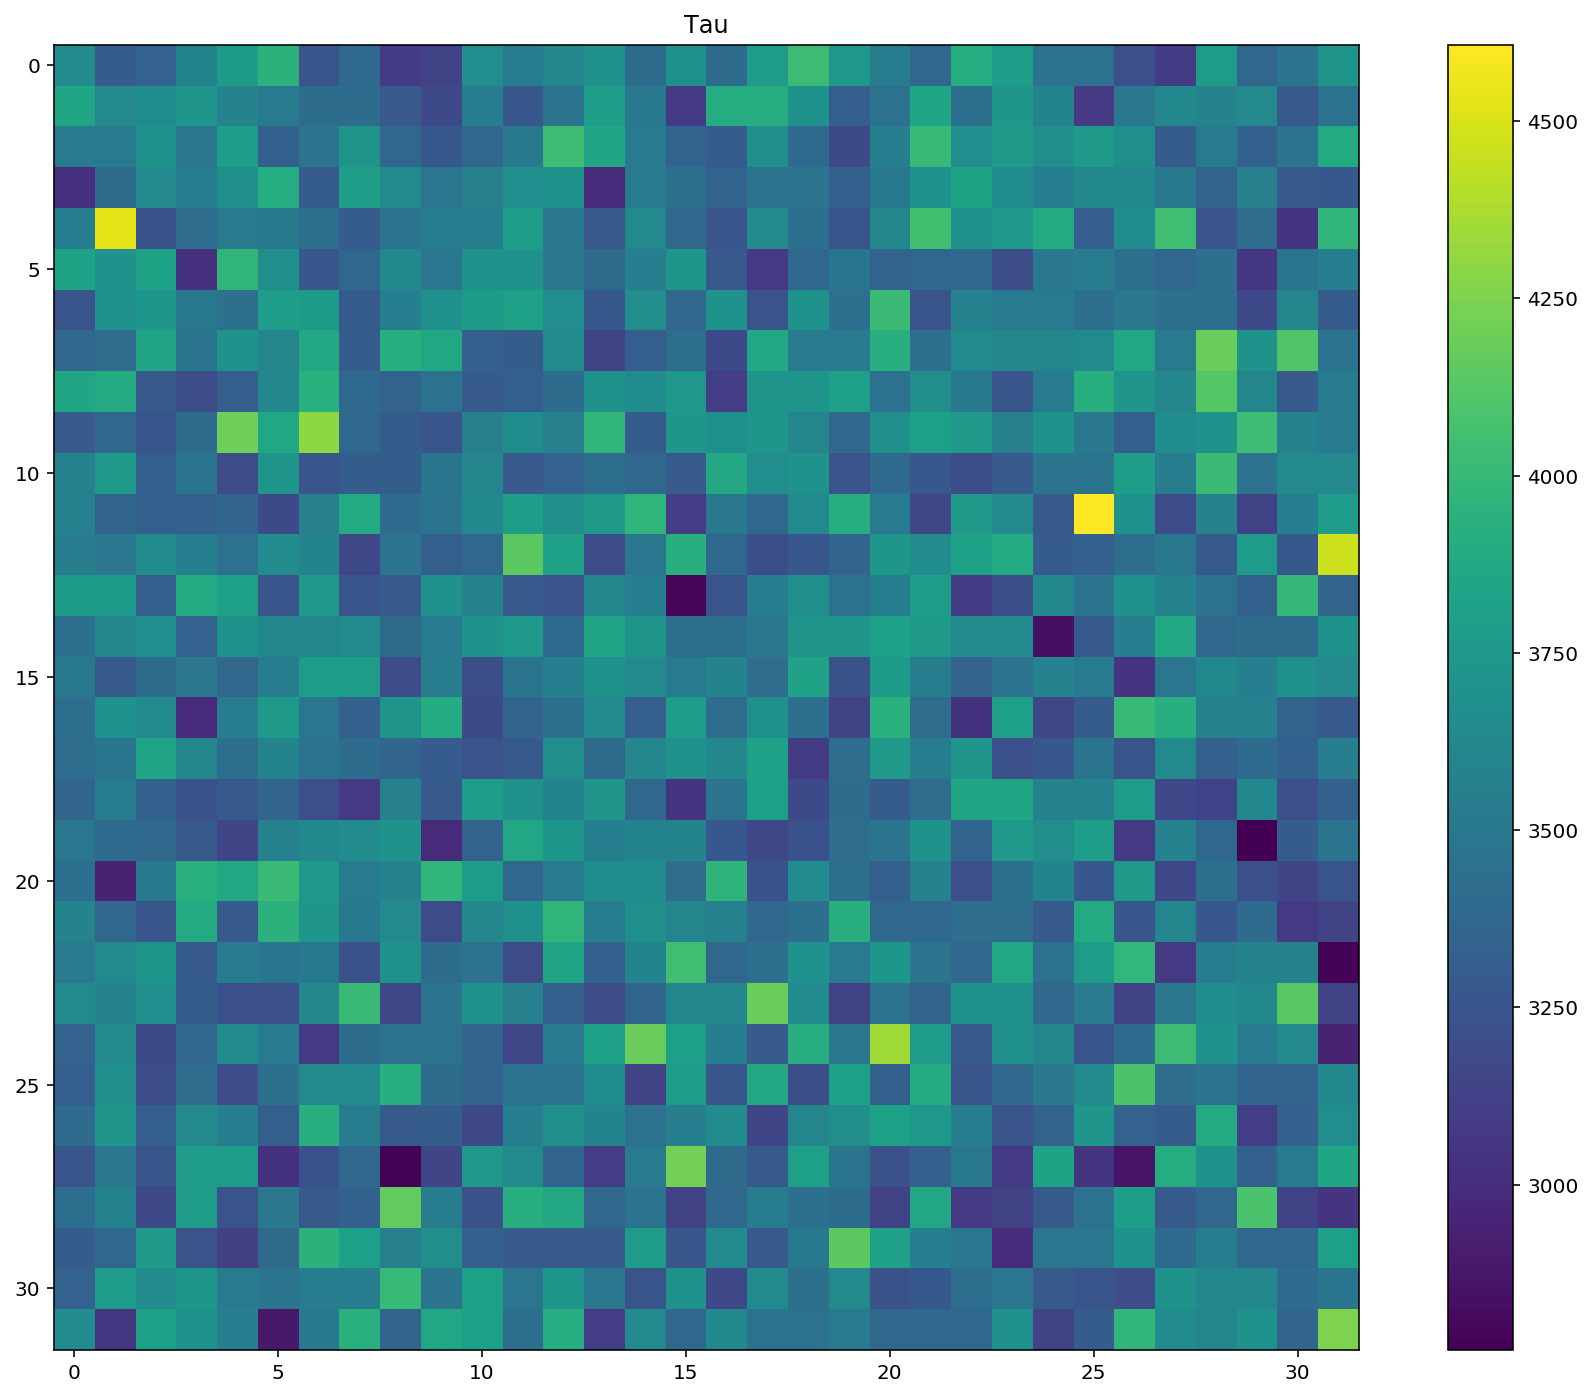

In [264]:
plt.imshow(flim_image[:, :, 2])
plt.title('Tau')
plt.colorbar()
plt.show()

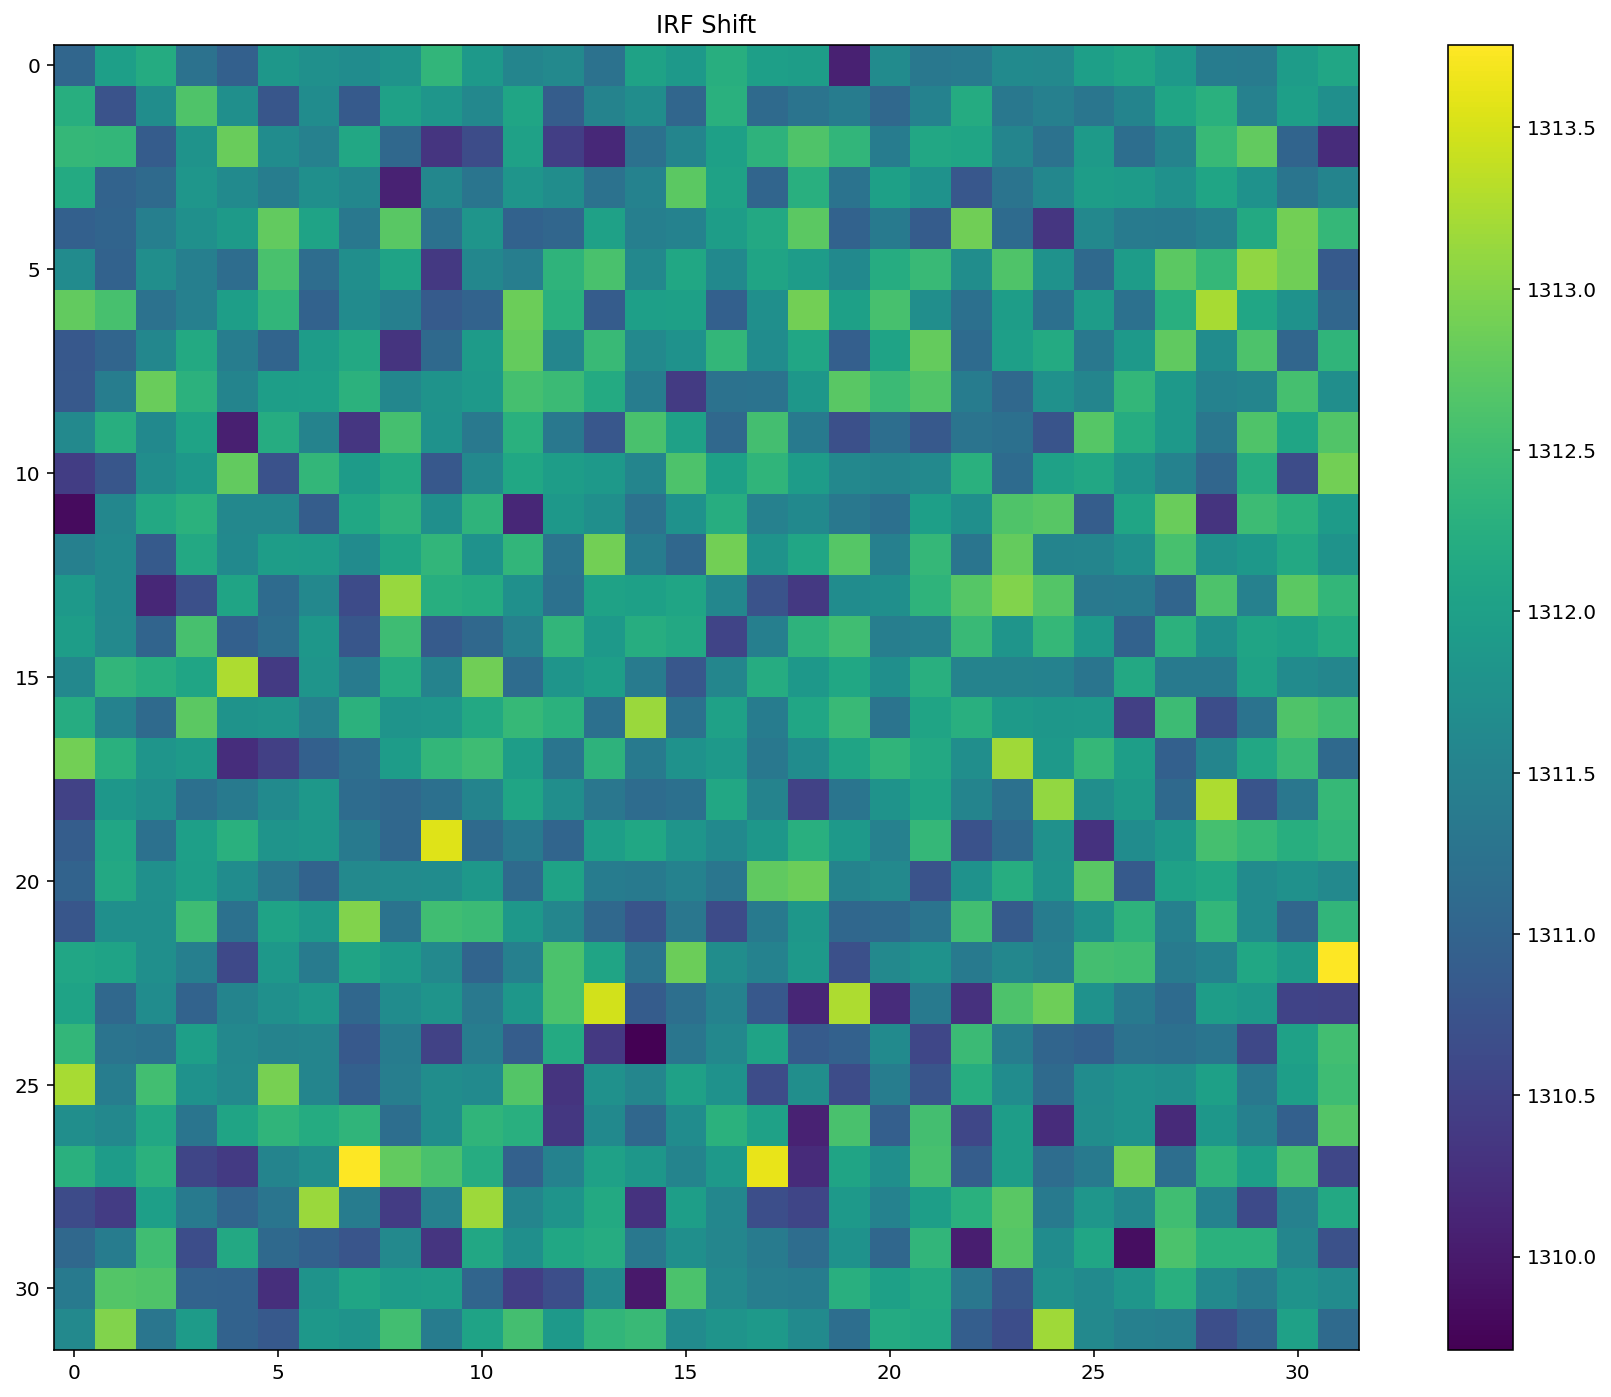

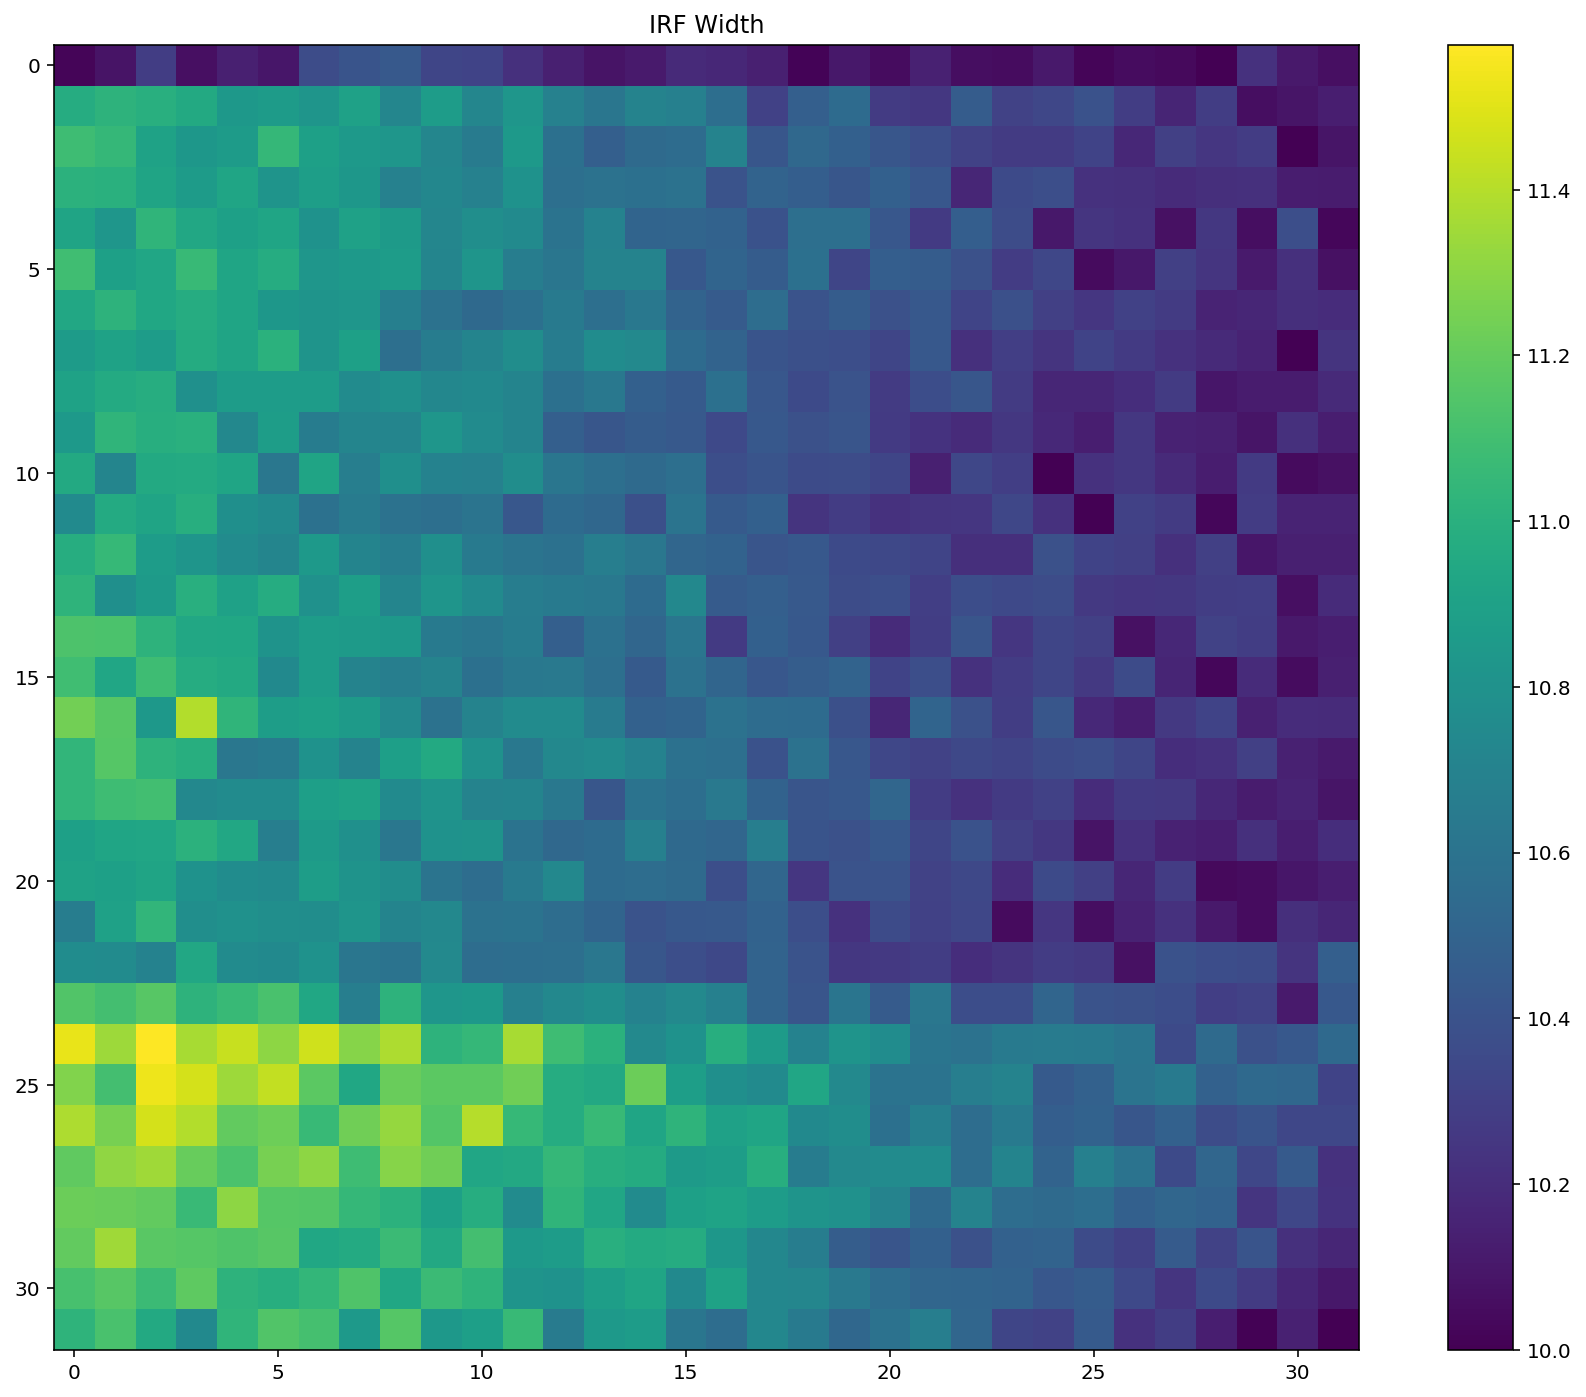

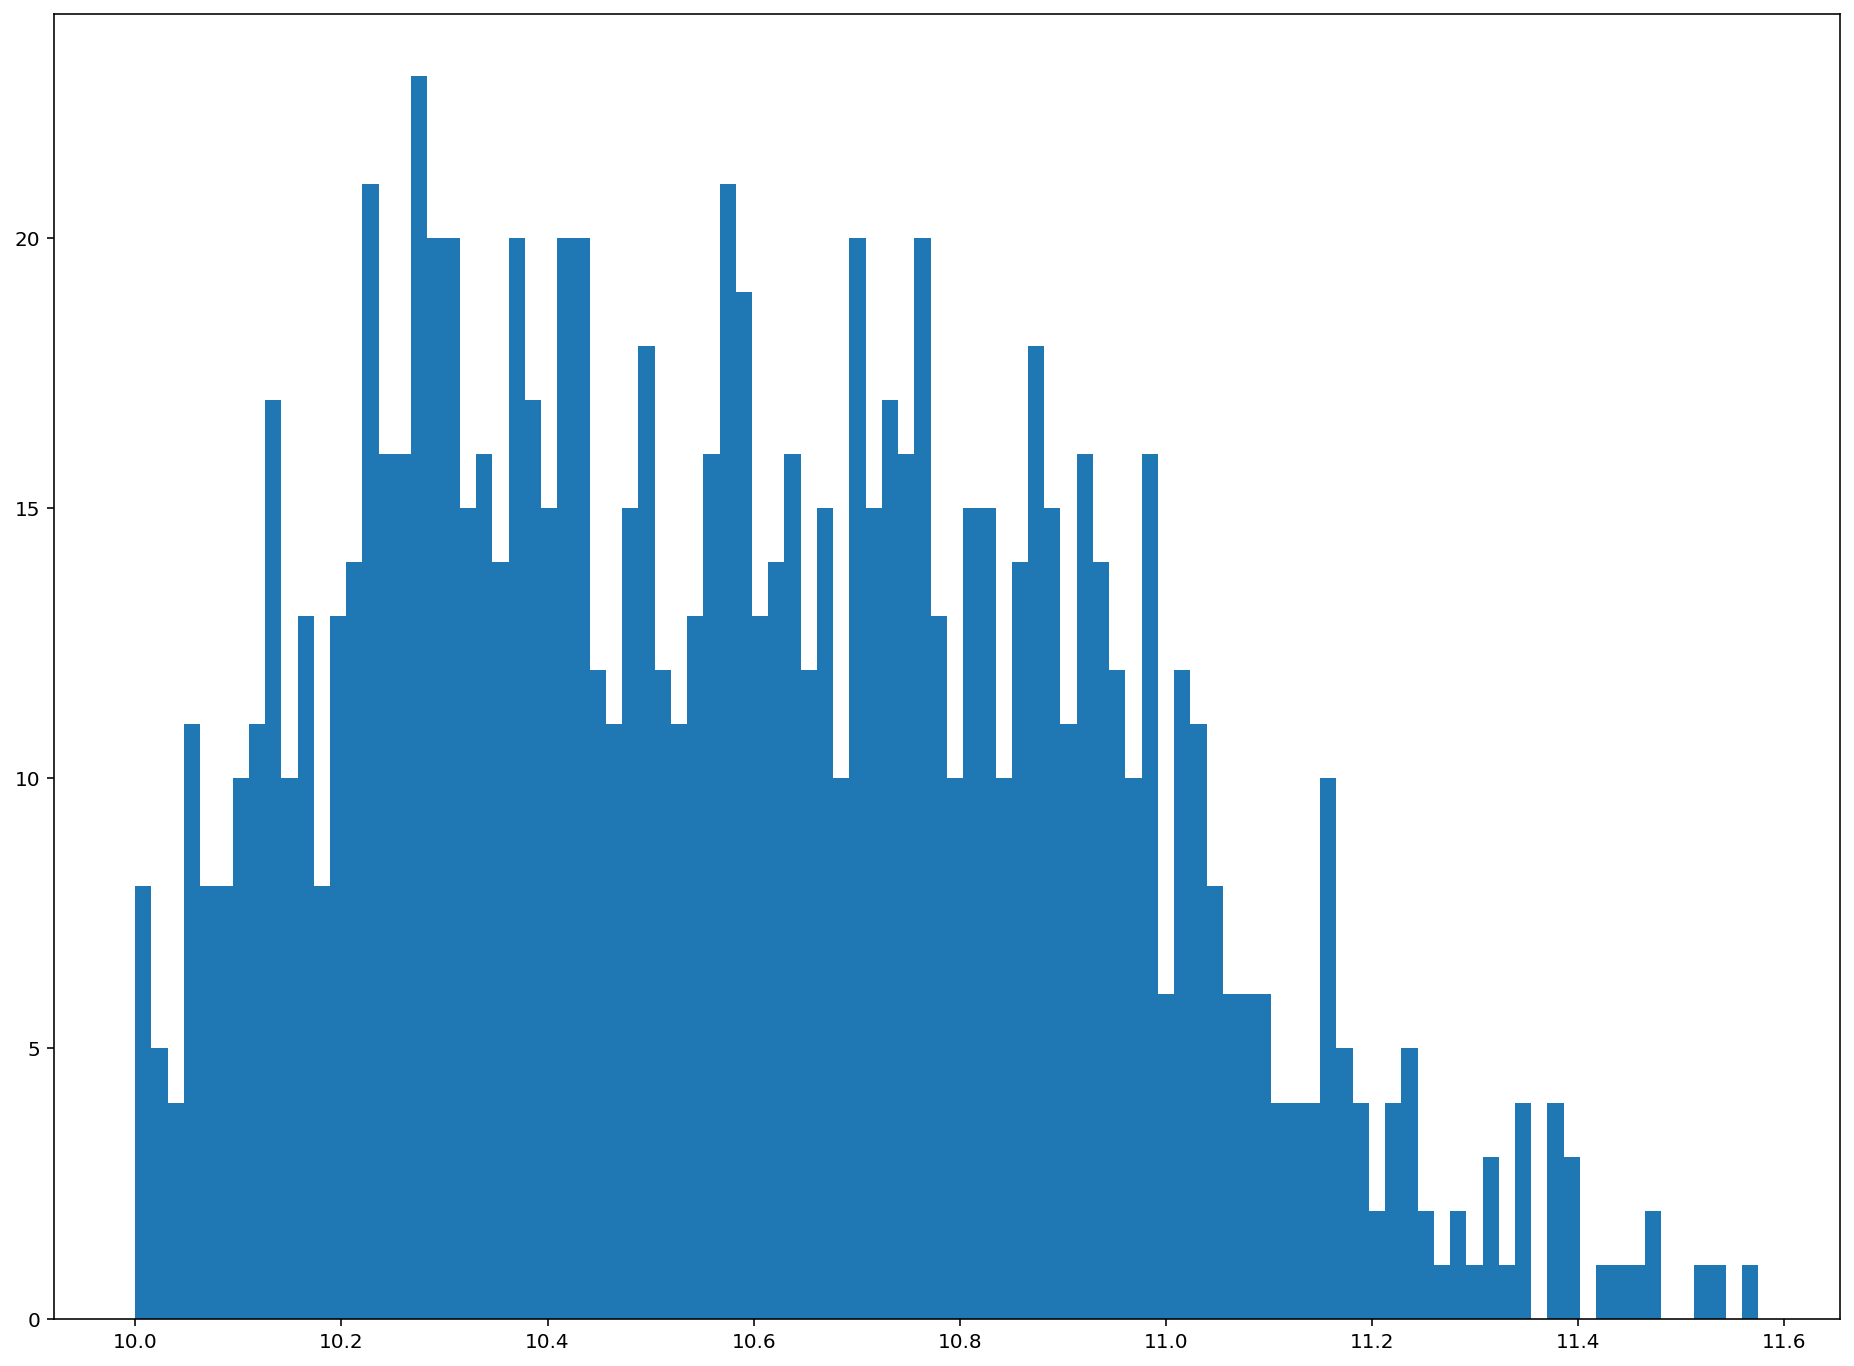

In [270]:
plt.imshow(flim_image[:, :, 3])
plt.title('IRF Shift')
plt.colorbar()
plt.show()

plt.imshow(flim_image[:, :, 4])
plt.title('IRF Width')
plt.colorbar()
plt.show()

plt.hist(flim_image[:, :, 4].flatten(), bins = 100)
plt.show()

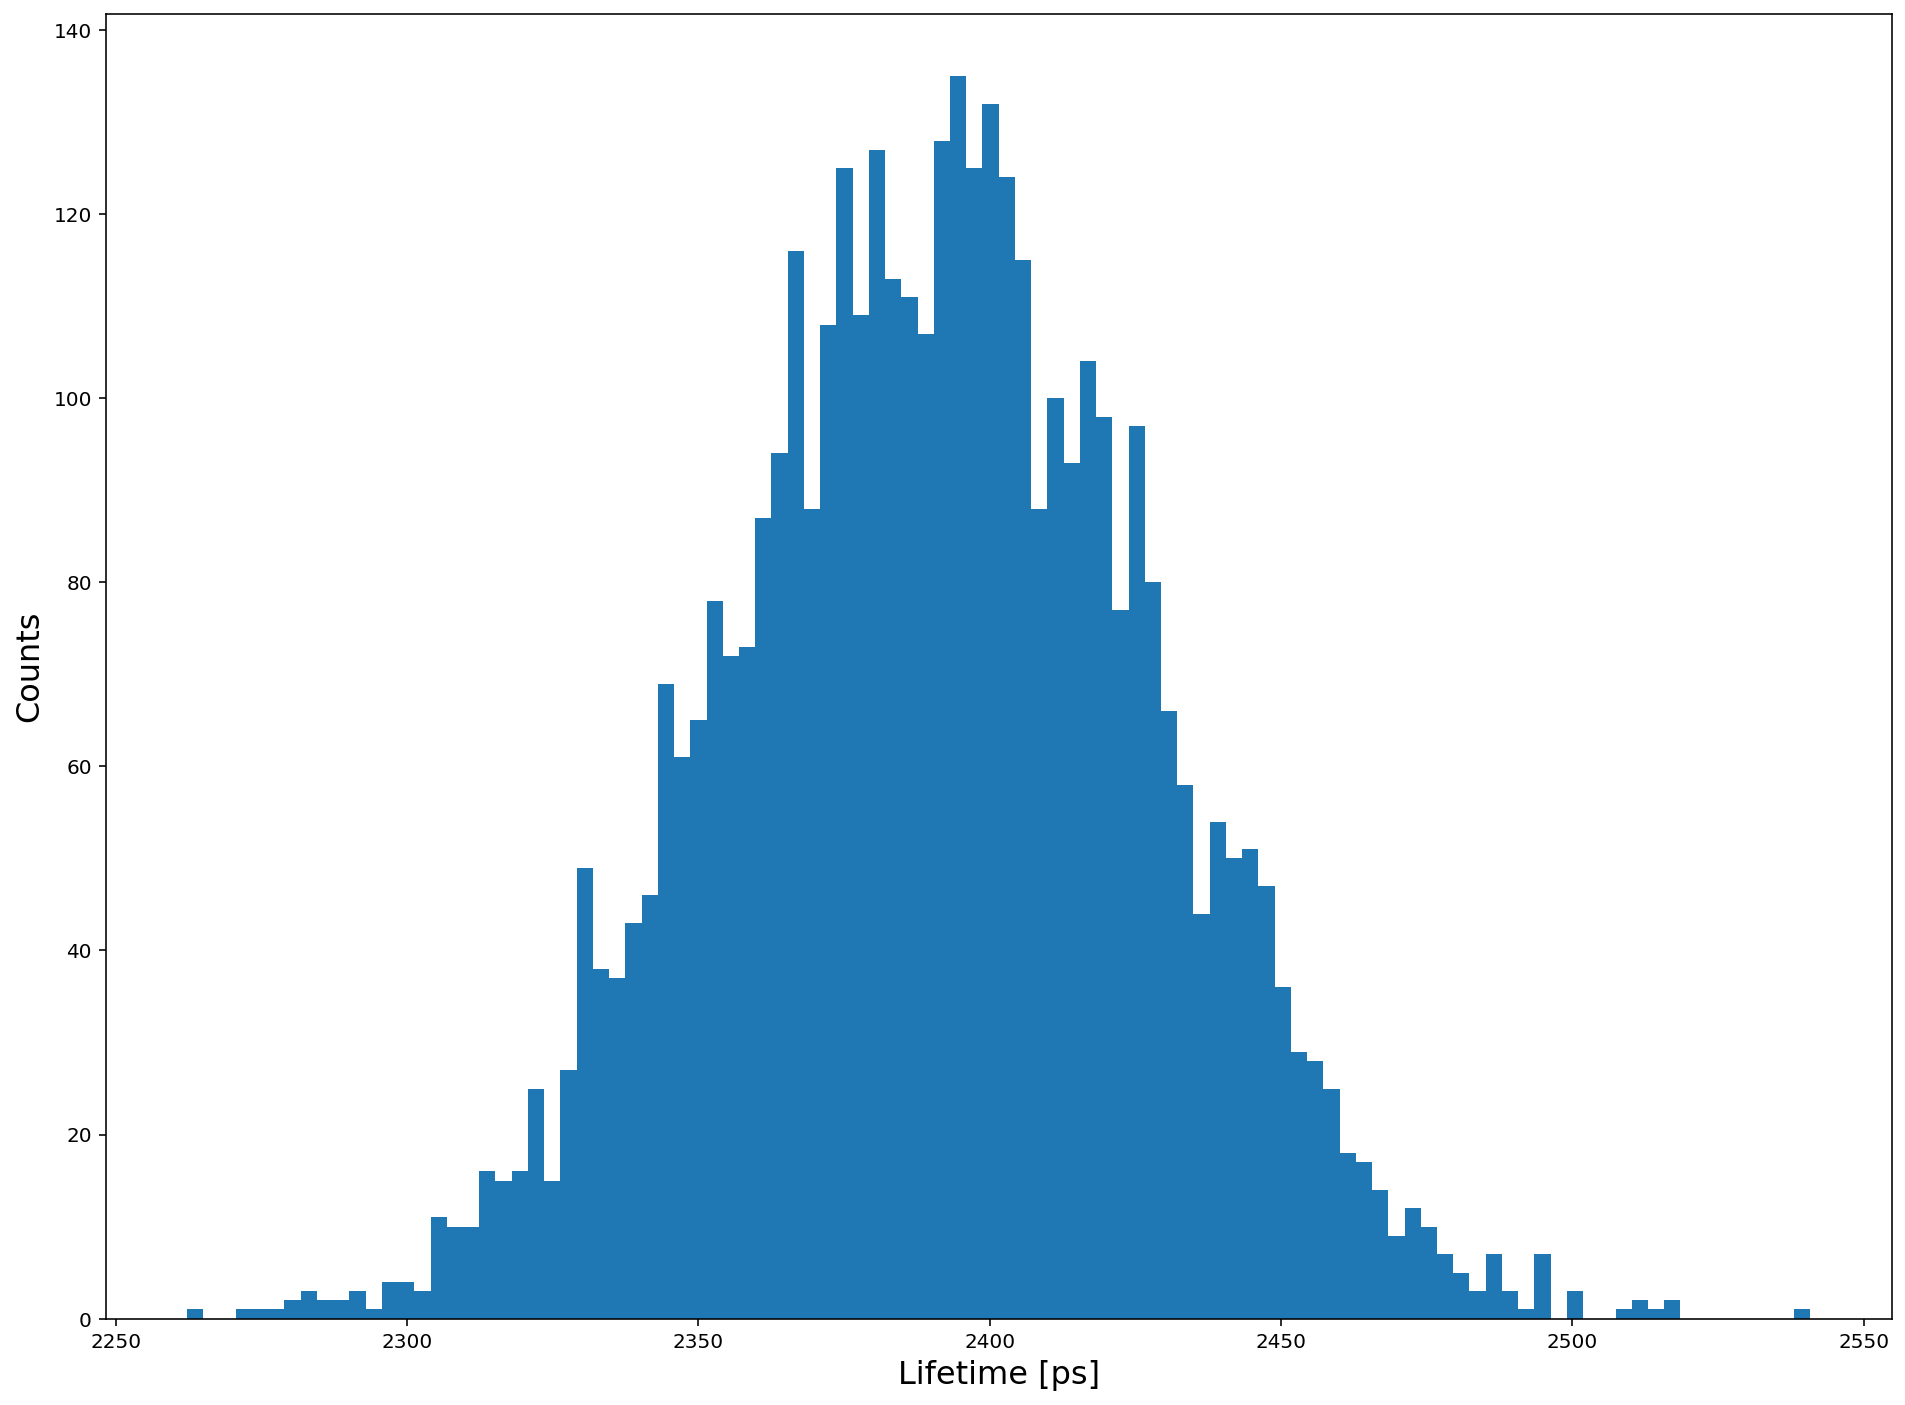

In [116]:
plt.hist(flim_image[:, :, 2].flatten(), bins = 100)
plt.xlabel('Lifetime [ps]')
plt.ylabel('Counts')
plt.show()

## Peak Maximum of Mirror-Measured IRF

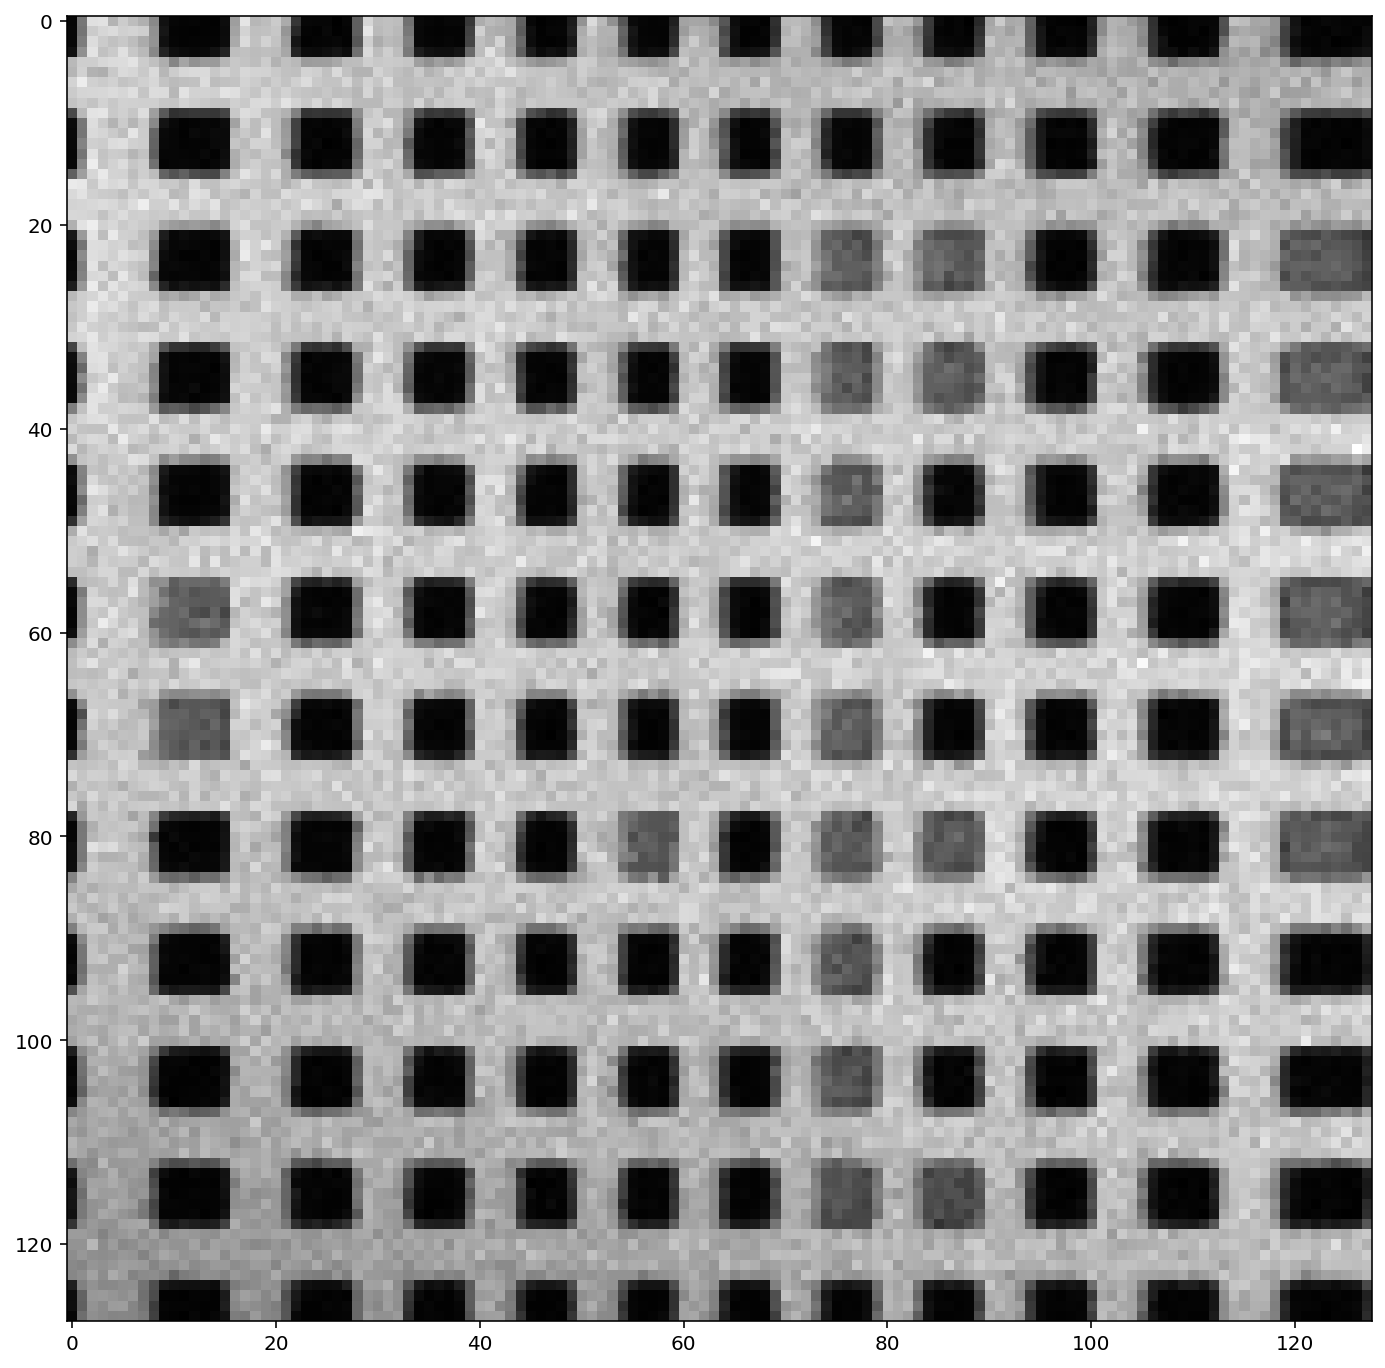

In [172]:
mirror, mirror_ii, time_axis = pq.load_flim_data(
    path = 'data/200302_Grid_Scan.sptw/200302_Grid_Zoom_4_7/200302_Grid_Zoom_4_7_1.ptu',
    spatialBinning = 3,
    temporalBinning = 2
)

plt.imshow(mirror_ii, cmap = 'gray')

In [173]:
peak_max = np.zeros((mirror.shape[0], mirror.shape[1]))

for x in range(mirror.shape[0]):
    for y in range(mirror.shape[1]):
        if(np.sum(mirror[x, y, :]) > 25):
            peak_max[x, y] = np.where(mirror[x, y, :] == np.amax(mirror[x, y, :]))[0][0]
        else:
            peak_max[x, y] = 0
            
peak_max *= 2**2

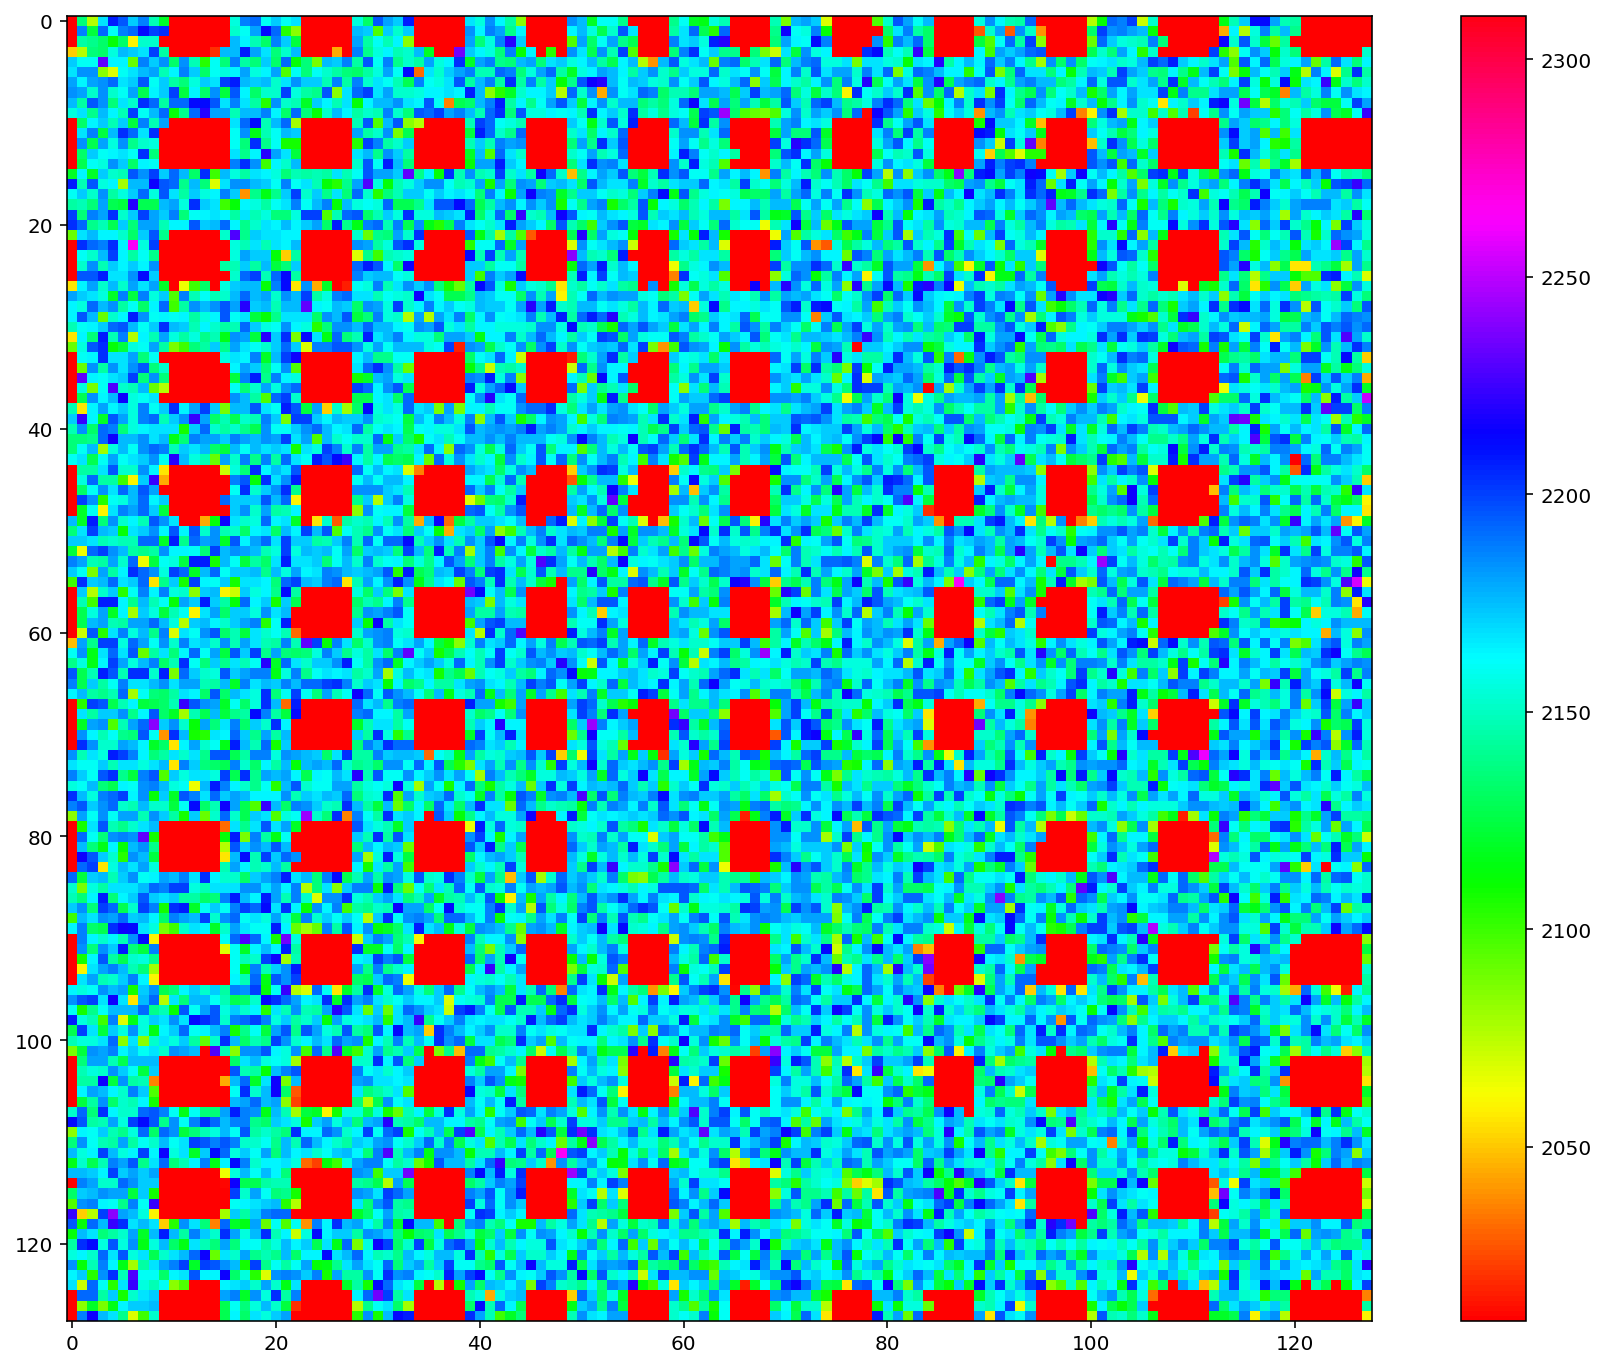

In [174]:
plt.imshow(peak_max,
           vmin = np.median(peak_max) - 150,
           vmax = np.median(peak_max) + 150,
          cmap = 'hsv')
plt.colorbar()
#plt.savefig('IRF_peak_shift_image.png', dpi = 350)
plt.show()

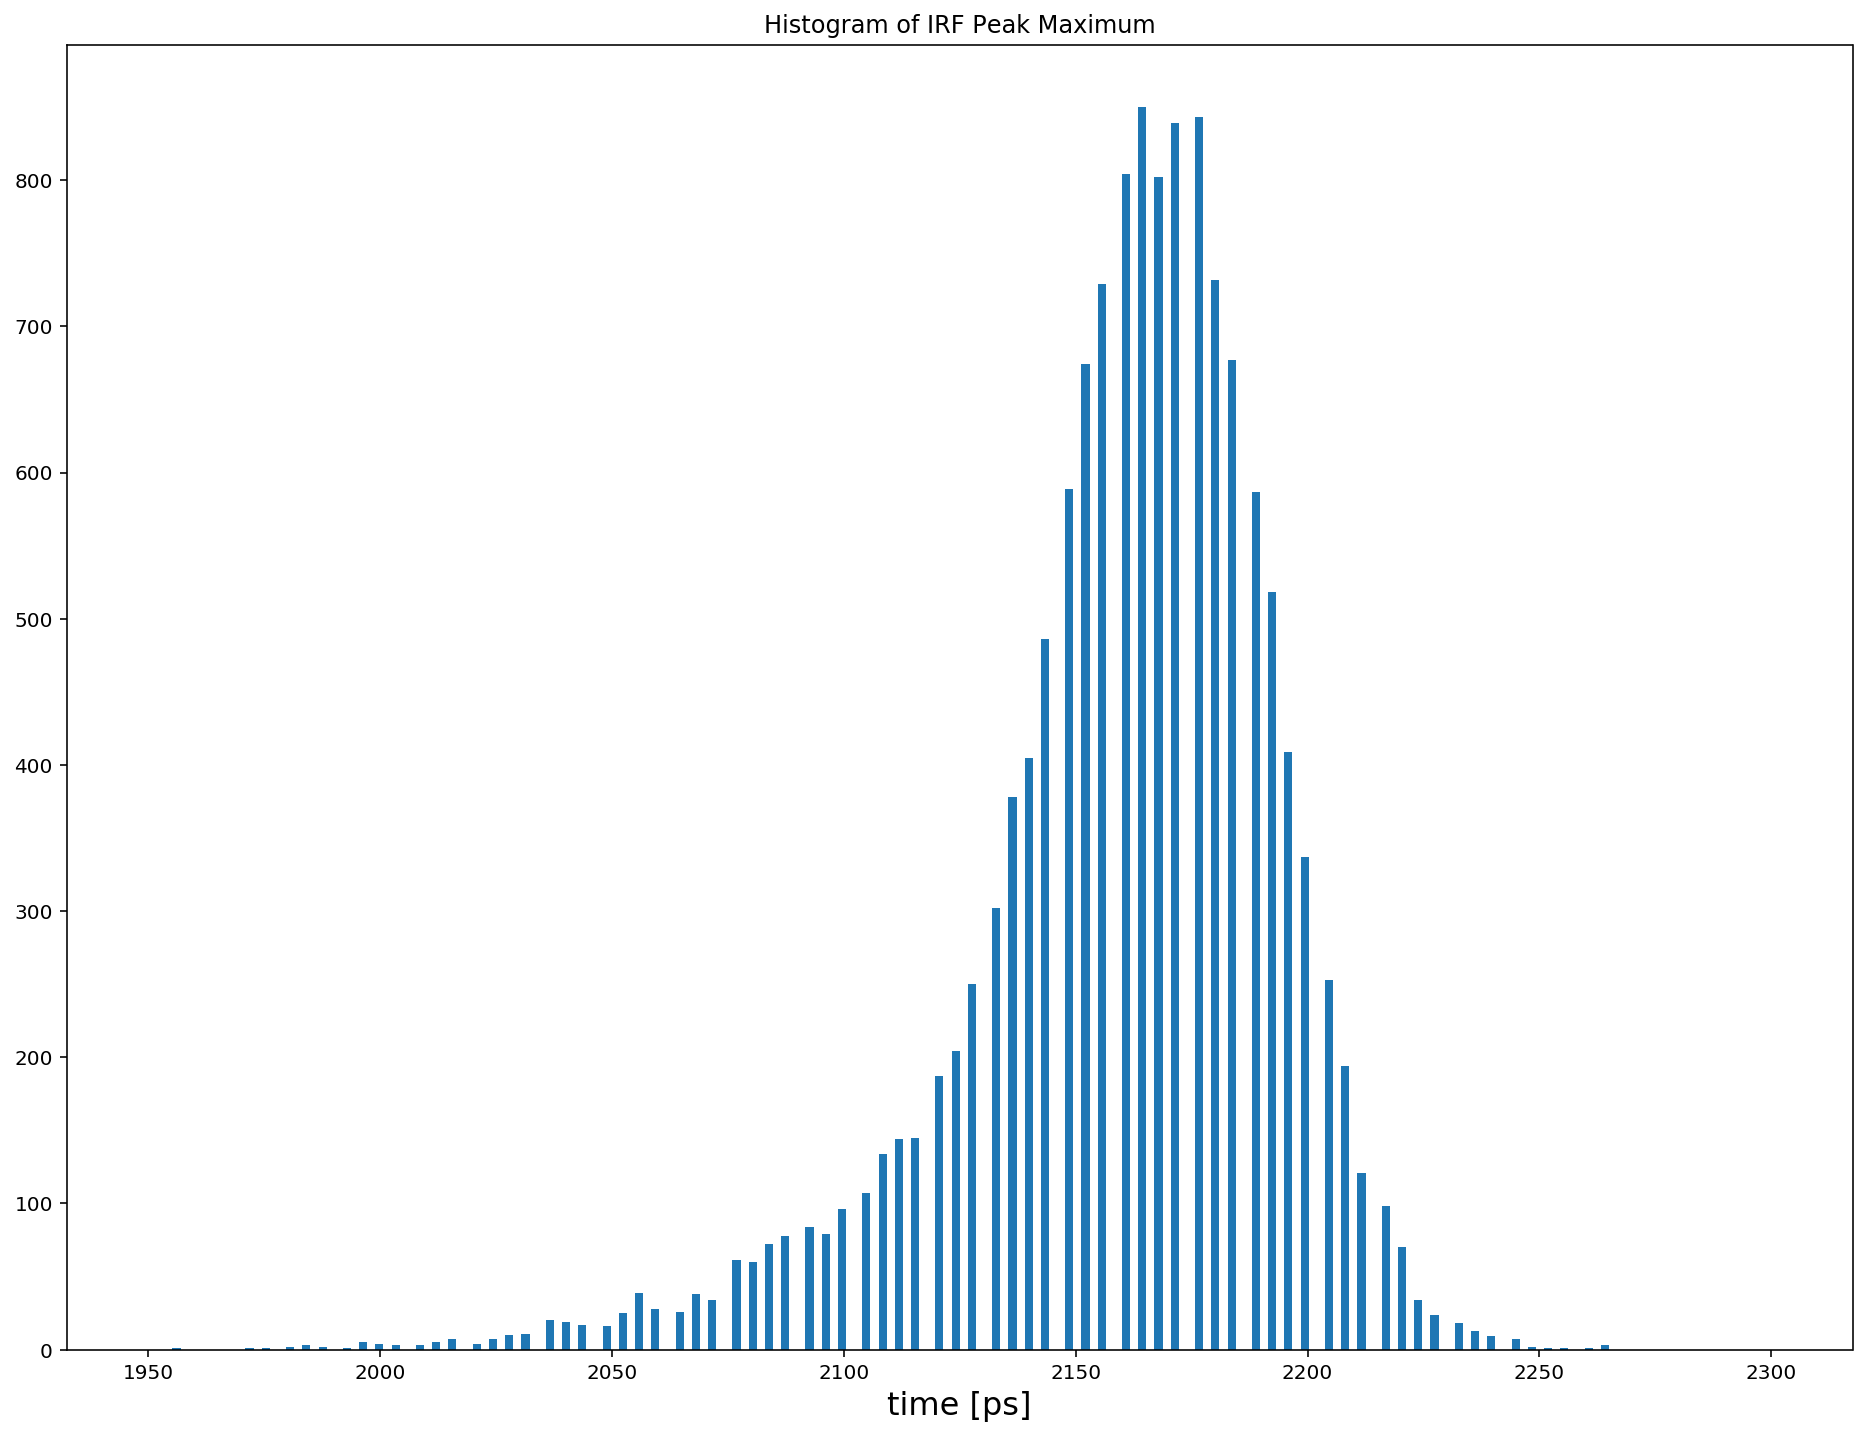

In [223]:
plt.hist(peak_max.flatten(), bins = 200, range = (1950, 2300))
plt.xlabel('time [ps]')
plt.title('Histogram of IRF Peak Maximum')
#plt.savefig('Hist_IRF_peak_time.png', dpi = 350)
plt.show()

IRF_shift_hist = np.histogram(peak_max.flatten(),
                              bins = 200,
                              range = (1950, 2300))

## Gewichtete Summe eines simulierten Decays mit dieser Verteilung von IRF_mu!!!

In [240]:
# Fluorescence Decay Simulation with IRF Shift Distribution from Grid Scan

time_axis = fit.make_time_axis(
    global_resolution = (1/19450000),
    resolution = 1.6E-11
)

sim_decay = np.zeros((time_axis.shape))

for i in range(len(IRF_shift_hist[0])):
    sim_decay += fit.convoluted_decay(
        t = time_axis,
        amp = IRF_shift_hist[0][i]*18,
        offset = 0,
        tau = 2500,
        IRF_mu = IRF_shift_hist[1][i],
        IRF_sigma = 60
    )
    
sim_decay = add_poisson_noise(sim_decay, offset = 10)

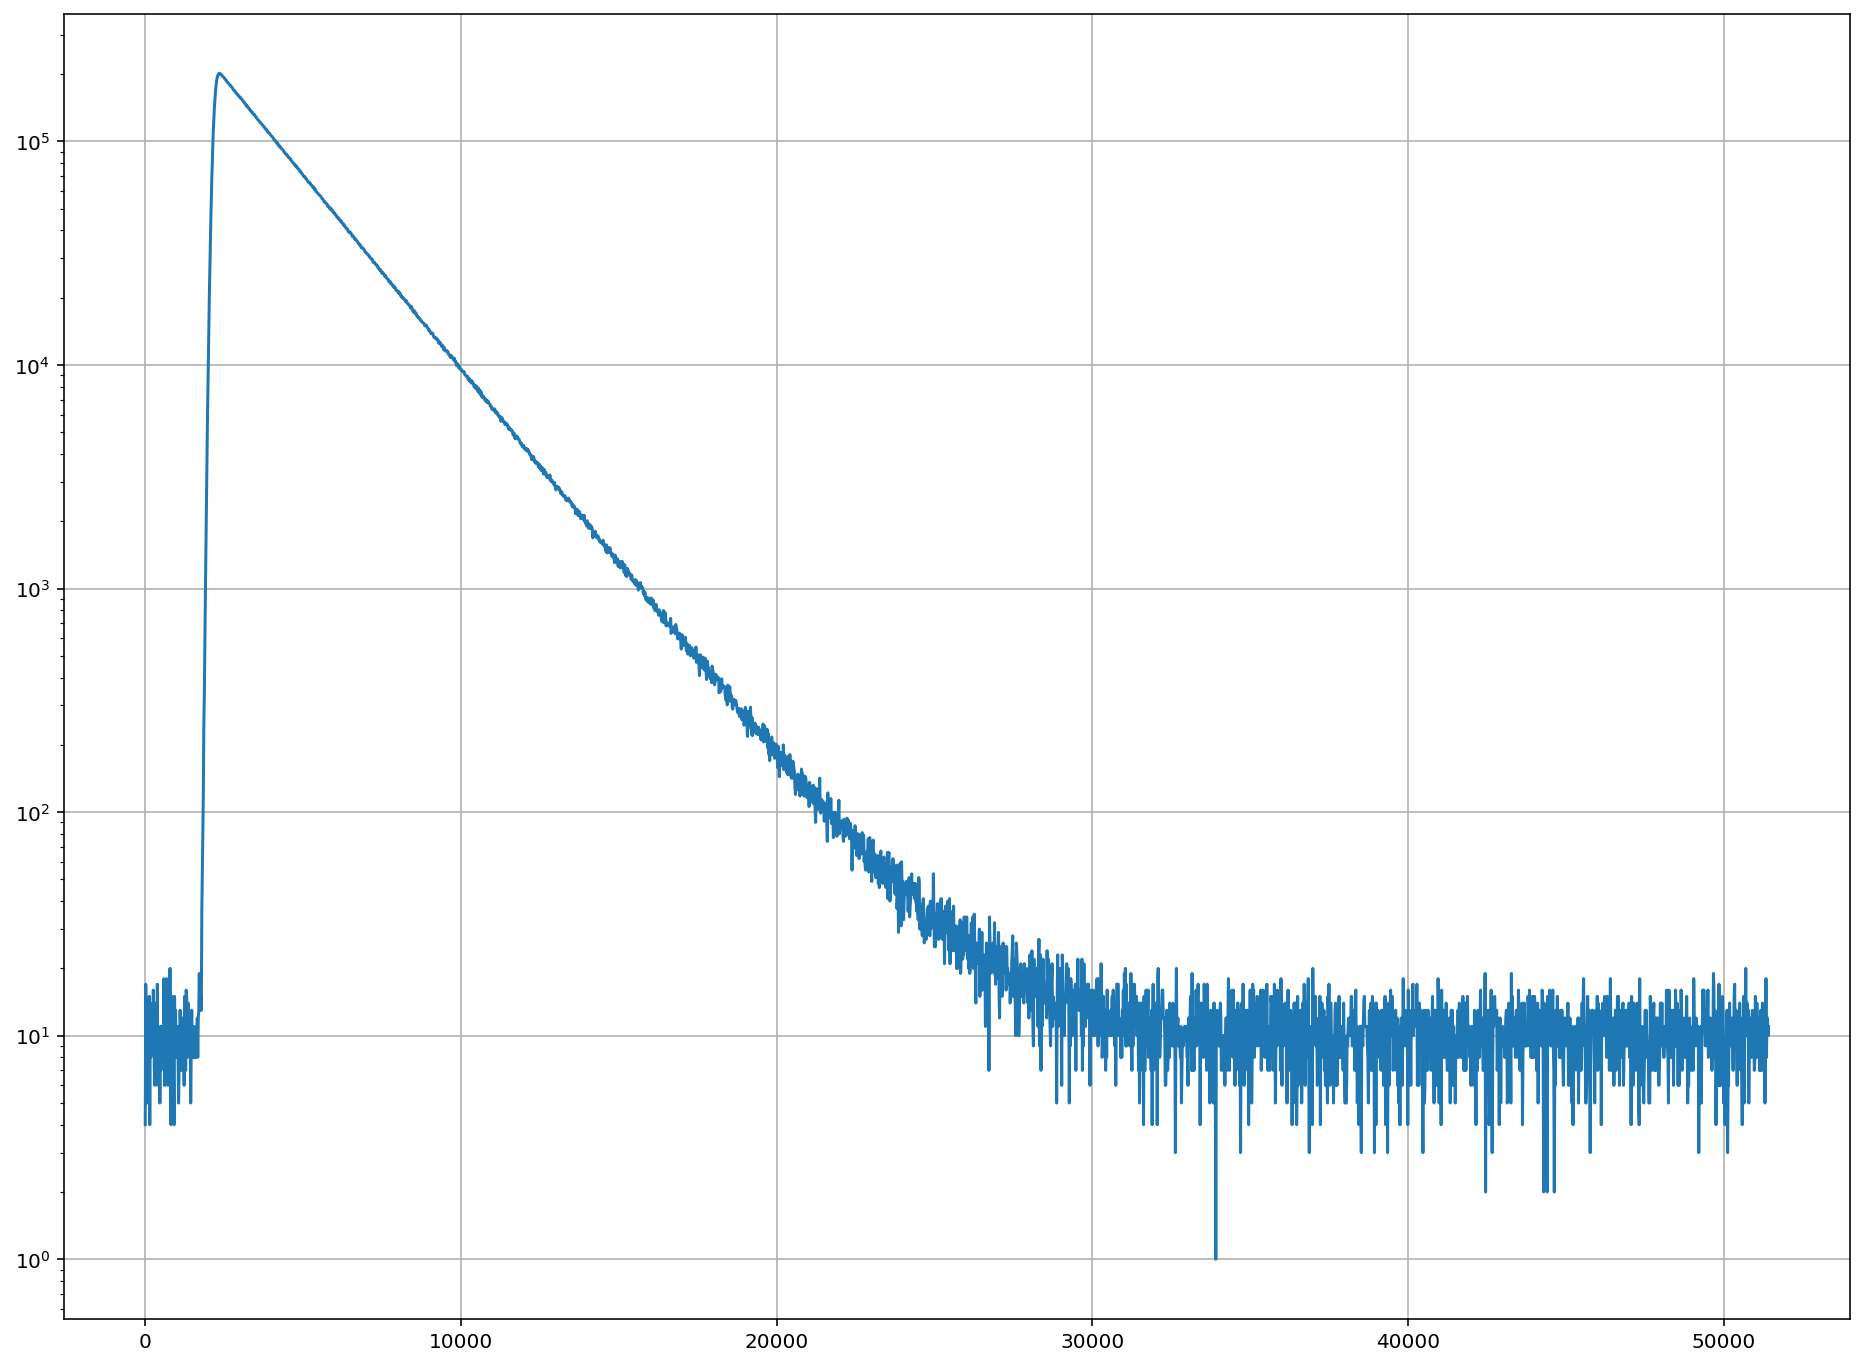

In [241]:
plt.plot(time_axis, sim_decay)
plt.grid()
plt.yscale('log')
#plt.xlim(0, 10000)
plt.show()

Reduced Chi-Squared: 1.470586797187396


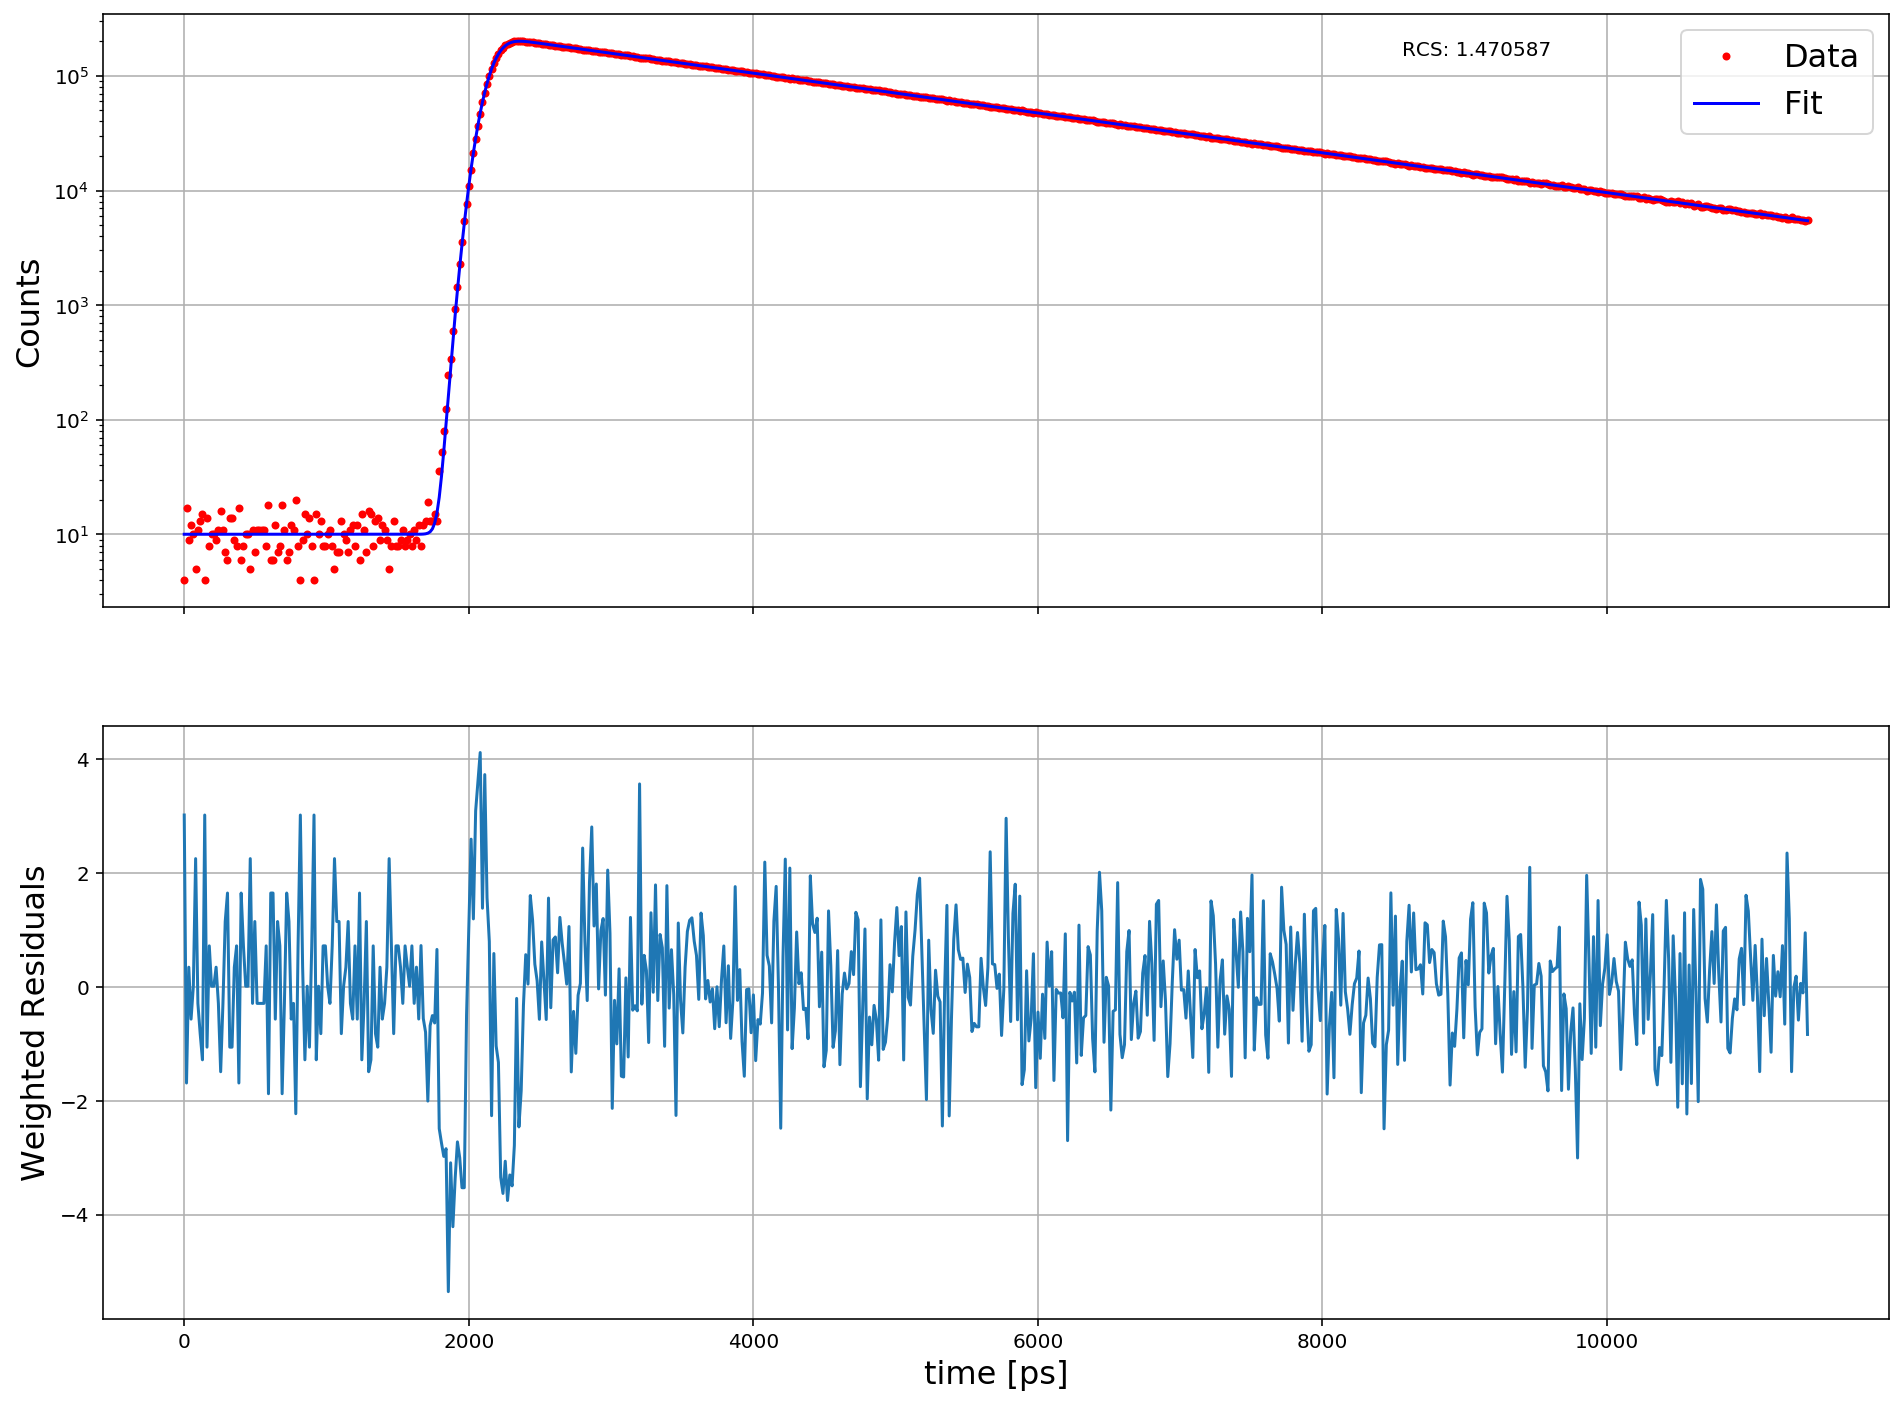

offset 		 10.029488671137743
amplitude 		 249238.6456792597
tau 		 2498.99835675902
IRF_mu 		 2159.835954282038
IRF_sigma 		 65.47199875976776


In [243]:
parameter_names, estimated_parameters, parameter_bounds = fit.make_start_parameters(
    offset = 10,
    amplitude = max(sim_decay),
    tau = 1500,
    IRF_sigma = 100,
    IRF_mu = 1000
)

simulated_fit = fit.fit_decay(
    sim_decay,
    time_axis,
    estimated_parameters,
    parameter_bounds,
    cutoff = 10,
    minimization_method = 'SLSQP'
)


fit.plot_fit(sim_decay, time_axis, simulated_fit, cutoff = 2500, scale = 'log')

for i in range(0, len(parameter_names)):
    print(parameter_names[i], '\t\t', simulated_fit['x'][i])